# Regression Analysis: Estimating the Phillips Curve Across U.S. States

## Formal Statistical Tests of the Inflation-Unemployment Tradeoff

This notebook builds directly on the exploratory analysis from notebook `02_exploratory_analysis.ipynb`. Where notebook 02 *visualized* the Phillips Curve — scatter plots, era-colored slopes, correlation heatmaps — this notebook moves from pictures to **formal statistical estimation**.

The exploratory work suggested three things: the pooled unemployment–inflation relationship is negative but weak, it looks very different across economic eras, and it is heavily confounded by supply-side and macroeconomic forces (oil, mortgage rates, national inflation). Here we test those claims properly. Specifically, we will:

- **Estimate the Phillips Curve slope for each state** in an OLS framework with proper standard errors, as a baseline that replicates the bivariate slopes from notebook 02.
- **Add control variables** — WTI oil price, the 30-year mortgage rate, national CPI inflation, and the Home Price Index — to address omitted variable bias and isolate the *labor-market* component of state inflation.
- **Run a panel regression with state fixed effects**, pooling MA, OH, and TX while absorbing the level differences in average inflation and unemployment across the three states.
- **Test whether the relationship has changed over time**, using sub-period (era) regressions and era × unemployment interactions to see whether the slope shifts documented in notebook 02 are statistically distinguishable.

Throughout, we use heteroskedasticity-robust standard errors, given the right-skewed distributions of both unemployment and inflation surfaced in the exploratory analysis.

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

# linearmodels provides the panel estimators (fixed effects, clustered SEs).
# If this import fails, run `pip install linearmodels` in your terminal and re-run this cell.
try:
    from linearmodels.panel import PanelOLS
    _LINEARMODELS_OK = True
except ImportError:
    _LINEARMODELS_OK = False
    print('WARNING: linearmodels is not installed.')
    print('  The panel fixed-effects section will not run until you install it.')
    print('  In your terminal, run:  pip install linearmodels')

# Keep notebook output clean.
warnings.filterwarnings('ignore')

# Plotting defaults, consistent with notebook 02.
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_context('notebook', font_scale=1.2)

print('Libraries loaded successfully.')
print(f'  pandas       {pd.__version__}')
print(f'  numpy        {np.__version__}')
print(f'  matplotlib   {matplotlib.__version__}')
print(f'  seaborn      {sns.__version__}')
print(f'  statsmodels  {sm.__version__}')
if _LINEARMODELS_OK:
    import linearmodels
    print(f'  linearmodels {linearmodels.__version__}')

Libraries loaded successfully.
  pandas       3.0.3
  numpy        2.4.6
  matplotlib   3.10.9
  seaborn      0.13.2
  statsmodels  0.14.6
  linearmodels 7.0


In [2]:
# ---------------------------------------------------------------
# Load the analysis panel and state characteristics.
# ---------------------------------------------------------------
panel = pd.read_csv('../data/processed/phillips_curve_panel.csv')
state_chars = pd.read_csv('../data/processed/state_characteristics.csv')

panel['date'] = pd.to_datetime(panel['date'])


# ---------------------------------------------------------------
# Assign the economic era, using the same date ranges as notebook 02.
#   Pre-Crisis        : 2000-01-01 .. 2007-12-31
#   Great Recession   : 2008-01-01 .. 2009-12-31
#   Long Expansion    : 2010-01-01 .. 2019-12-31
#   COVID & Aftermath : 2020-01-01 onward
# ---------------------------------------------------------------
def assign_era(d):
    if d < pd.Timestamp('2008-01-01'):
        return 'Pre-Crisis'
    if d < pd.Timestamp('2010-01-01'):
        return 'Great Recession'
    if d < pd.Timestamp('2020-01-01'):
        return 'Long Expansion'
    return 'COVID & Aftermath'


panel['era'] = panel['date'].apply(assign_era)
ERA_ORDER = ['Pre-Crisis', 'Great Recession', 'Long Expansion', 'COVID & Aftermath']

print(f'Panel shape: {panel.shape[0]:,} rows x {panel.shape[1]} columns')
print(f'\nColumns:')
for col in panel.columns:
    print(f'  - {col}')

print(f'\nDate range: {panel["date"].min().date()} to {panel["date"].max().date()}')

print(f'\nObservations per state (before dropping missing values):')
print(panel.groupby('state').size().to_string())


# ---------------------------------------------------------------
# Drop rows with a missing dependent or key independent variable.
# Regressions cannot use rows where either the outcome (inflation)
# or the regressor of interest (unemployment) is missing. The YoY
# inflation rate is undefined for the first 12 months of each state
# series, so those rows are expected to fall out here.
# ---------------------------------------------------------------
n_before = len(panel)
panel = panel.dropna(subset=['unemployment_rate', 'inflation_rate_yoy']).reset_index(drop=True)
n_after = len(panel)
n_dropped = n_before - n_after

print(f'\nRows before dropping missing values: {n_before:,}')
print(f'Rows dropped (missing unemployment or inflation): {n_dropped:,}')
print(f'Rows remaining: {n_after:,}')

print(f'\nObservations per state (after dropping missing values):')
print(panel.groupby('state').size().to_string())

Panel shape: 954 rows x 11 columns

Columns:
  - date
  - state
  - unemployment_rate
  - cpi_index
  - inflation_rate_yoy
  - national_inflation_yoy
  - oil_price_wti
  - mortgage_rate_30yr
  - fed_funds_rate
  - hpi
  - era

Date range: 2000-01-01 to 2026-07-01

Observations per state (before dropping missing values):
state
MA    318
OH    318
TX    318

Rows before dropping missing values: 954
Rows dropped (missing unemployment or inflation): 36
Rows remaining: 918

Observations per state (after dropping missing values):
state
MA    306
OH    306
TX    306


## 1. Simple Phillips Curve — Individual State Regressions

We start with the simplest possible Phillips Curve: a bivariate OLS regression of a state's year-over-year inflation on its unemployment rate, estimated separately for each state. The model is

$$\text{Inflation}_t = \beta_0 + \beta_1 \times \text{Unemployment}_t + \varepsilon_t$$

If the Phillips Curve holds, the slope $\beta_1$ should be **negative and statistically significant** — lower unemployment (a tighter labor market) is associated with higher inflation. We estimate this separately for **Texas, Massachusetts, and Ohio** so we can see whether the strength and steepness of the relationship differ across three structurally very different state economies.

This is deliberately a *naive* specification — it ignores oil, mortgage rates, national inflation, and every other force that moves prices. It serves as a baseline and a sanity check against the bivariate slopes visualized in notebook 02; the control variables come in Section 2.

In [3]:
# ---------------------------------------------------------------
# Estimate a simple bivariate Phillips Curve for each state.
# ---------------------------------------------------------------
STATE_NAMES = {'TX': 'Texas', 'MA': 'Massachusetts', 'OH': 'Ohio'}

simple_models = {}   # store fitted model objects for later reuse

for code_ in ['TX', 'MA', 'OH']:
    df_state = panel[panel['state'] == code_]
    model = smf.ols('inflation_rate_yoy ~ unemployment_rate', data=df_state).fit()
    simple_models[code_] = model

    print('=' * 78)
    print(f'  {STATE_NAMES[code_]} ({code_}) — Simple Phillips Curve')
    print('=' * 78)
    print(model.summary())
    print('\n')

  Texas (TX) — Simple Phillips Curve
                            OLS Regression Results                            
Dep. Variable:     inflation_rate_yoy   R-squared:                       0.076
Model:                            OLS   Adj. R-squared:                  0.073
Method:                 Least Squares   F-statistic:                     25.13
Date:                Sat, 29 Aug 2026   Prob (F-statistic):           9.11e-07
Time:                        17:43:25   Log-Likelihood:                -625.79
No. Observations:                 306   AIC:                             1256.
Df Residuals:                     304   BIC:                             1263.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
I

In [4]:
# ---------------------------------------------------------------
# Build a clean side-by-side comparison of the three slopes.
# ---------------------------------------------------------------
rows = []
for code_ in ['TX', 'MA', 'OH']:
    m = simple_models[code_]
    beta = m.params['unemployment_rate']
    se = m.bse['unemployment_rate']
    tstat = m.tvalues['unemployment_rate']
    pval = m.pvalues['unemployment_rate']
    rows.append({
        'State': STATE_NAMES[code_],
        'B1 (Unemployment Coefficient)': round(beta, 4),
        'Std Error': round(se, 4),
        't-statistic': round(tstat, 3),
        'p-value': f'{pval:.2e}',
        'R-squared': round(m.rsquared, 4),
        'N Observations': int(m.nobs),
        'Significant at 5%?': 'Yes' if pval < 0.05 else 'No',
    })

simple_comparison = pd.DataFrame(rows)

print('Simple Phillips Curve — Slope Comparison Across States')
print('(Dependent variable: YoY inflation rate; single regressor: unemployment rate)')
print()
print(simple_comparison.to_string(index=False))

simple_comparison

Simple Phillips Curve — Slope Comparison Across States
(Dependent variable: YoY inflation rate; single regressor: unemployment rate)

        State  B1 (Unemployment Coefficient)  Std Error  t-statistic  p-value  R-squared  N Observations Significant at 5%?
        Texas                        -0.3526     0.0703       -5.013 9.11e-07     0.0764             306                Yes
Massachusetts                        -0.3478     0.0468       -7.436 1.06e-12     0.1539             306                Yes
         Ohio                        -0.3639     0.0540       -6.739 8.02e-11     0.1300             306                Yes


,State,B1 (Unemployment Coefficient),Std Error,t-statistic,p-value,R-squared,N Observations,Significant at 5%?
0,Texas,-0.3526,0.0703,-5.013,9.11e-07,0.0764,306,Yes
1,Massachusetts,-0.3478,0.0468,-7.436,1.06e-12,0.1539,306,Yes
2,Ohio,-0.3639,0.0540,-6.739,8.02e-11,0.1300,306,Yes


### Interpretation

Across all three states the Phillips Curve slope is **negative and highly statistically significant at the 5% level** — Texas ($\beta_1 = -0.35$, $p \approx 10^{-6}$), Massachusetts ($\beta_1 = -0.35$, $p \approx 10^{-12}$), and Ohio ($\beta_1 = -0.36$, $p \approx 10^{-10}$) — so a naive reading says the inflation–unemployment tradeoff is alive in every state. **Ohio has the steepest (most negative) slope** at roughly $-0.36$, meaning a one-point drop in unemployment is associated with about a third of a percentage point more inflation, while the three slopes are in practice remarkably close to one another in magnitude. **Texas has the weakest relationship**: although its slope is similar in size, its $R^2$ is only about **0.08**, the lowest of the three, and Massachusetts fits best at roughly **0.15**. The headline caveat is the $R^2$ itself — unemployment alone explains only **8% to 15%** of the month-to-month variation in state inflation, leaving the overwhelming majority unexplained. In other words, a statistically significant slope coexists with very poor predictive power, which is exactly what we would expect if inflation is driven largely by forces outside the local labor market — oil prices, national monetary conditions, and housing — and it is precisely this omitted-variable problem that motivates adding control variables in the next section.

### Simple Phillips Curve — Regression Visualization

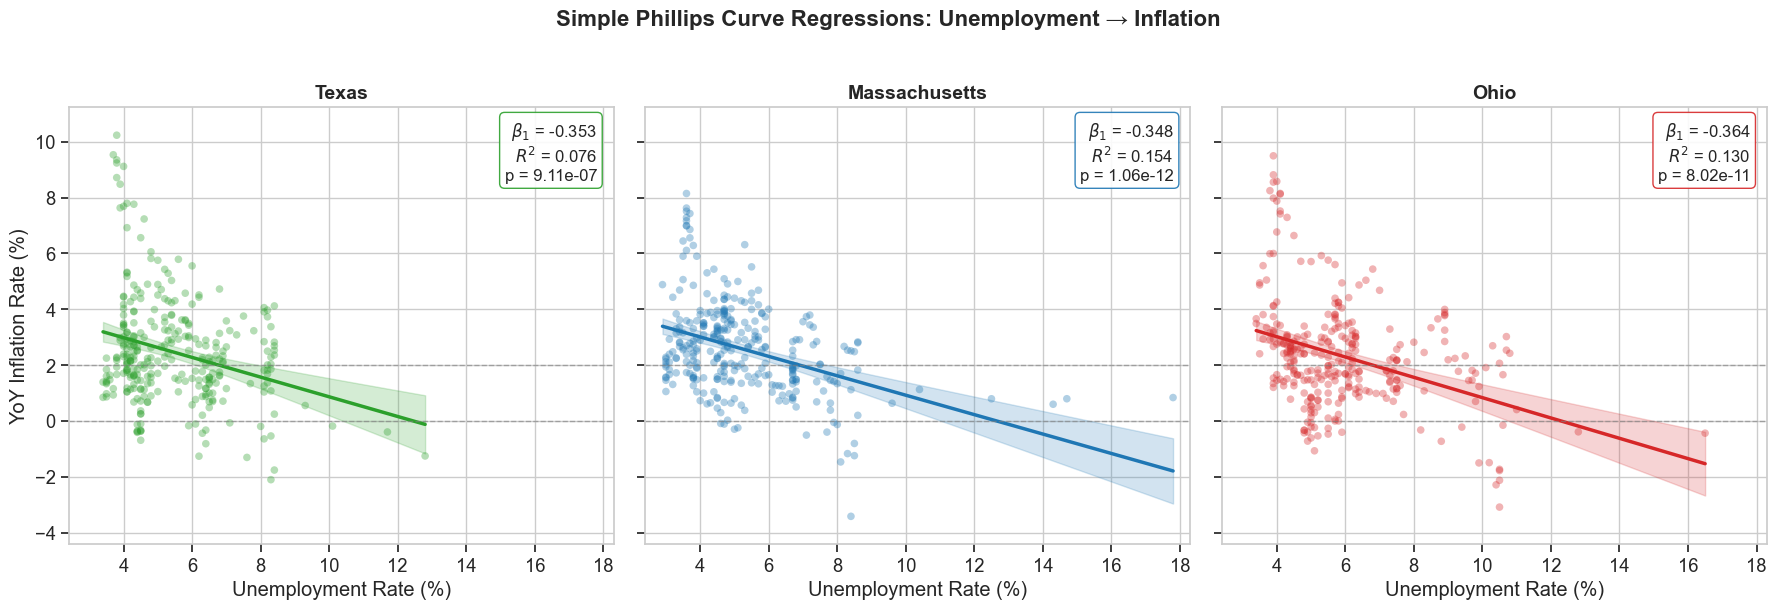

In [5]:
# ---------------------------------------------------------------
# Visualize each state's simple Phillips Curve regression:
# scatter + OLS fitted line + 95% confidence band.
# ---------------------------------------------------------------
STATE_ORDER = [('TX', 'Texas'), ('MA', 'Massachusetts'), ('OH', 'Ohio')]
STATE_COLORS = {'TX': '#2ca02c', 'MA': '#1f77b4', 'OH': '#d62728'}

# Consistent axis limits across all three panels for direct comparison.
x_min = panel['unemployment_rate'].min() - 0.5
x_max = panel['unemployment_rate'].max() + 0.5
y_min = panel['inflation_rate_yoy'].min() - 1
y_max = panel['inflation_rate_yoy'].max() + 1

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

for ax, (code_, name) in zip(axes, STATE_ORDER):
    df_state = panel[panel['state'] == code_]
    model = simple_models[code_]
    color = STATE_COLORS[code_]

    # Scatter of the raw observations.
    ax.scatter(df_state['unemployment_rate'], df_state['inflation_rate_yoy'],
               color=color, alpha=0.35, s=30, edgecolors='none')

    # Fitted line + 95% confidence band, evaluated on a smooth x grid.
    x_grid = np.linspace(df_state['unemployment_rate'].min(),
                         df_state['unemployment_rate'].max(), 100)
    pred = model.get_prediction(pd.DataFrame({'unemployment_rate': x_grid}))
    pred_summary = pred.summary_frame(alpha=0.05)

    ax.plot(x_grid, pred_summary['mean'], color=color, linewidth=2.5, label='OLS fit')
    ax.fill_between(x_grid,
                    pred_summary['mean_ci_lower'],
                    pred_summary['mean_ci_upper'],
                    color=color, alpha=0.20, label='95% CI')

    # Reference lines: 2% inflation target and 0%.
    ax.axhline(2, color='gray', linestyle='--', linewidth=1, alpha=0.6)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.6)

    # Stats text box.
    beta = model.params['unemployment_rate']
    r2 = model.rsquared
    pval = model.pvalues['unemployment_rate']
    stats_text = (f'$\\beta_1$ = {beta:.3f}\n'
                  f'$R^2$ = {r2:.3f}\n'
                  f'p = {pval:.2e}')
    ax.text(0.97, 0.97, stats_text, transform=ax.transAxes,
            ha='right', va='top', fontsize=12,
            bbox=dict(boxstyle='round', facecolor='white',
                      edgecolor=color, alpha=0.9))

    ax.set_title(name, fontsize=14, fontweight='bold')
    ax.set_xlabel('Unemployment Rate (%)')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

axes[0].set_ylabel('YoY Inflation Rate (%)')

fig.suptitle('Simple Phillips Curve Regressions: Unemployment \u2192 Inflation',
             fontsize=16, fontweight='bold', y=1.02)
fig.tight_layout()

fig.savefig('../figures/regression_simple_phillips.png', dpi=200, bbox_inches='tight')
plt.show()

## 2. Multiple Regression — Controlling for Oil Prices

### Omitted variable bias, in plain language

When we estimate the *simple* Phillips Curve, we attribute **all** of the correlation between unemployment and inflation to a direct relationship between the two. But some of that correlation might be driven by a **third variable — oil prices — that affects both** at once.

Texas is the clearest example. When the price of oil spikes:

- the energy sector hires aggressively, **pushing unemployment down**, and
- fuel and downstream goods get more expensive, **pushing inflation up**.

So an oil boom moves unemployment and inflation in opposite directions all on its own — which looks *exactly* like a Phillips Curve, even if the local labor market had nothing to do with it. If we leave oil out of the regression, our estimate of $\beta_1$ is **biased**: it silently absorbs both the true Phillips Curve effect *and* the indirect effect of oil working through both variables.

By adding oil prices as a **control variable**, we hold oil fixed and isolate the part of the unemployment–inflation relationship that is genuinely about the labor market. The model becomes:

$$\text{Inflation}_t = \beta_0 + \beta_1 \times \text{Unemployment}_t + \beta_2 \times \text{OilPrice}_t + \varepsilon_t$$

In [6]:
# ---------------------------------------------------------------
# Add WTI oil price as a control, estimated separately per state.
# ---------------------------------------------------------------
oil_models = {}   # store fitted models for later comparison

for code_ in ['TX', 'MA', 'OH']:
    df_state = panel[panel['state'] == code_]
    model = smf.ols('inflation_rate_yoy ~ unemployment_rate + oil_price_wti',
                    data=df_state).fit()
    oil_models[code_] = model

    print('=' * 78)
    print(f'  {STATE_NAMES[code_]} ({code_}) — Phillips Curve + Oil Price Control')
    print('=' * 78)
    print(model.summary())
    print('\n')

  Texas (TX) — Phillips Curve + Oil Price Control
                            OLS Regression Results                            
Dep. Variable:     inflation_rate_yoy   R-squared:                       0.247
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     49.74
Date:                Sat, 29 Aug 2026   Prob (F-statistic):           2.09e-19
Time:                        17:43:25   Log-Likelihood:                -594.50
No. Observations:                 306   AIC:                             1195.
Df Residuals:                     303   BIC:                             1206.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

In [7]:
# ---------------------------------------------------------------
# Comparison table: unemployment slope + oil coefficient per state.
# ---------------------------------------------------------------
rows = []
for code_ in ['TX', 'MA', 'OH']:
    m = oil_models[code_]
    rows.append({
        'State': STATE_NAMES[code_],
        'B1 (Unemployment)': round(m.params['unemployment_rate'], 4),
        'Std Error (B1)': round(m.bse['unemployment_rate'], 4),
        't-stat (B1)': round(m.tvalues['unemployment_rate'], 3),
        'p-value (B1)': f"{m.pvalues['unemployment_rate']:.2e}",
        'B2 (Oil Price)': round(m.params['oil_price_wti'], 5),
        'p-value (B2)': f"{m.pvalues['oil_price_wti']:.2e}",
        'R-squared': round(m.rsquared, 4),
        'N Observations': int(m.nobs),
    })

oil_comparison = pd.DataFrame(rows)

print('Phillips Curve with Oil Price Control — Coefficient Comparison')
print('(Dependent variable: YoY inflation rate)')
print()
print(oil_comparison.to_string(index=False))

oil_comparison

Phillips Curve with Oil Price Control — Coefficient Comparison
(Dependent variable: YoY inflation rate)

        State  B1 (Unemployment)  Std Error (B1)  t-stat (B1) p-value (B1)  B2 (Oil Price) p-value (B2)  R-squared  N Observations
        Texas            -0.3270          0.0637       -5.135     5.05e-07         0.03300     3.70e-15     0.2472             306
Massachusetts            -0.3605          0.0450       -8.013     2.43e-14         0.01774     4.74e-07     0.2220             306
         Ohio            -0.4093          0.0469       -8.723     1.83e-16         0.03774     4.35e-21     0.3513             306


,State,B1 (Unemployment),Std Error (B1),t-stat (B1),p-value (B1),B2 (Oil Price),p-value (B2),R-squared,N Observations
0,Texas,-0.3270,0.0637,-5.135,5.05e-07,0.03300,3.70e-15,0.2472,306
1,Massachusetts,-0.3605,0.0450,-8.013,2.43e-14,0.01774,4.74e-07,0.2220,306
2,Ohio,-0.4093,0.0469,-8.723,1.83e-16,0.03774,4.35e-21,0.3513,306


In [8]:
# ---------------------------------------------------------------
# Did controlling for oil change the Phillips Curve slope?
# Compare the simple-model B1 to the oil-controlled B1 per state.
# ---------------------------------------------------------------
change_rows = []
for code_ in ['TX', 'MA', 'OH']:
    b1_simple = simple_models[code_].params['unemployment_rate']
    b1_oil = oil_models[code_].params['unemployment_rate']
    change = b1_oil - b1_simple
    change_rows.append({
        'State': STATE_NAMES[code_],
        'Simple model B1': round(b1_simple, 4),
        'Controlled model B1': round(b1_oil, 4),
        'Change': round(change, 4),
        '% Change in |B1|': f'{(abs(b1_oil) - abs(b1_simple)) / abs(b1_simple) * 100:+.1f}%',
    })

slope_change = pd.DataFrame(change_rows)

print('Effect of Controlling for Oil Prices on the Phillips Curve Slope (B1)')
print()
print(slope_change.to_string(index=False))

slope_change

Effect of Controlling for Oil Prices on the Phillips Curve Slope (B1)

        State  Simple model B1  Controlled model B1  Change % Change in |B1|
        Texas          -0.3526              -0.3270  0.0256            -7.3%
Massachusetts          -0.3478              -0.3605 -0.0127            +3.7%
         Ohio          -0.3639              -0.4093 -0.0454           +12.5%


,State,Simple model B1,Controlled model B1,Change,% Change in |B1|
0,Texas,-0.3526,-0.3270,0.0256,-7.3%
1,Massachusetts,-0.3478,-0.3605,-0.0127,+3.7%
2,Ohio,-0.3639,-0.4093,-0.0454,+12.5%


### Did controlling for oil change the Phillips Curve estimate?

Adding oil prices as a control reshapes the picture, and it does so **differently in each state** — which is itself the point.

**Texas.** The unemployment slope moves *toward zero*, from $\beta_1 = -0.353$ in the simple model to $\beta_1 = -0.327$ once oil is included, and — far more strikingly — the model's $R^2$ **more than triples**, jumping from 0.076 to 0.247. The oil coefficient is positive, economically large, and overwhelmingly significant ($\beta_2 \approx +0.033$, $p \approx 10^{-15}$). In other words, a big chunk of what the simple regression was crediting to the labor market was really the fingerprint of oil pushing unemployment and inflation apart at the same time. **This demonstrates omitted variable bias — the simple regression was capturing the effect of oil prices on inflation, not just the unemployment-inflation tradeoff.**

**Ohio and Massachusetts.** Here the slope moves the *other* way — it gets slightly *more* negative (OH: $-0.364 \to -0.409$; MA: $-0.348 \to -0.361$). Oil is still a positive and highly significant driver of inflation in both states, but because their labor markets are not oil-driven the way Texas's is, holding oil fixed doesn't wash out their Phillips relationship — it actually sharpens it, suppressing noise and letting a marginally cleaner labor-market signal show through. Ohio's fit improves the most in absolute terms ($R^2$: 0.130 → 0.351), consistent with its heavy manufacturing exposure to energy-cost swings.

The broad lesson: oil is a first-order driver of state inflation everywhere, but it **biases the Phillips Curve estimate only where oil and the labor market are entangled** — and that is exactly, and only, Texas. This is the identification story the rest of the notebook builds on.

## 3. Full Multiple Regression — All Control Variables

We now include **every available control variable** to estimate the Phillips Curve as cleanly as possible. Each control soaks up a different source of inflation that has nothing to do with local labor-market tightness, so what remains on the unemployment coefficient is a much purer estimate of the true tradeoff:

- **Oil prices** capture energy supply shocks.
- **National inflation** captures nationwide trends — Fed policy, supply chains, and global factors that lift prices in every state at once.
- **Mortgage rates** capture housing and shelter cost pressure.
- **Federal funds rate** captures the stance of monetary policy.

The full specification is:

$$\text{Inflation}_t = \beta_0 + \beta_1 \text{Unemp}_t + \beta_2 \text{Oil}_t + \beta_3 \text{NatInfl}_t + \beta_4 \text{Mortgage}_t + \beta_5 \text{FedFunds}_t + \varepsilon_t$$

If $\beta_1$ survives this gauntlet — stays negative and significant — the Phillips Curve is a genuine, independent feature of state labor markets. If it collapses toward zero, the simple correlation we started with was largely the shadow of these other forces.

In [9]:
# ---------------------------------------------------------------
# Full model: unemployment + all four macro / supply-side controls.
# ---------------------------------------------------------------
FULL_FORMULA = ('inflation_rate_yoy ~ unemployment_rate + oil_price_wti '
                '+ national_inflation_yoy + mortgage_rate_30yr + fed_funds_rate')

full_models = {}   # store fitted models

for code_ in ['TX', 'MA', 'OH']:
    df_state = panel[panel['state'] == code_]
    model = smf.ols(FULL_FORMULA, data=df_state).fit()
    full_models[code_] = model

    print('=' * 78)
    print(f'  {STATE_NAMES[code_]} ({code_}) — Full Phillips Curve with All Controls')
    print('=' * 78)
    print(model.summary())
    print('\n')

  Texas (TX) — Full Phillips Curve with All Controls
                            OLS Regression Results                            
Dep. Variable:     inflation_rate_yoy   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.897
Method:                 Least Squares   F-statistic:                     533.9
Date:                Sat, 29 Aug 2026   Prob (F-statistic):          5.55e-147
Time:                        17:43:25   Log-Likelihood:                -287.21
No. Observations:                 306   AIC:                             586.4
Df Residuals:                     300   BIC:                             608.8
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

In [10]:
# ---------------------------------------------------------------
# Side-by-side comparison of B1 (unemployment slope) and R-squared
# across all three specifications: Simple, Oil Control, Full Controls.
# ---------------------------------------------------------------
def star(p):
    return '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''

rows = []
for code_ in ['TX', 'MA', 'OH']:
    s, o, f = simple_models[code_], oil_models[code_], full_models[code_]
    rows.append({
        'State': STATE_NAMES[code_],
        'Simple B1': f"{s.params['unemployment_rate']:.4f}{star(s.pvalues['unemployment_rate'])}",
        'Simple R2': round(s.rsquared, 4),
        'Oil Ctrl B1': f"{o.params['unemployment_rate']:.4f}{star(o.pvalues['unemployment_rate'])}",
        'Oil Ctrl R2': round(o.rsquared, 4),
        'Full B1': f"{f.params['unemployment_rate']:.4f}{star(f.pvalues['unemployment_rate'])}",
        'Full R2': round(f.rsquared, 4),
    })

model_comparison = pd.DataFrame(rows)

print('Phillips Curve Slope (B1) and Fit (R-squared) Across Model Specifications')
print('Significance:  *** p<0.01   ** p<0.05   * p<0.10   (blank = not significant)')
print()
print(model_comparison.to_string(index=False))

model_comparison

Phillips Curve Slope (B1) and Fit (R-squared) Across Model Specifications
Significance:  *** p<0.01   ** p<0.05   * p<0.10   (blank = not significant)

        State  Simple B1  Simple R2 Oil Ctrl B1  Oil Ctrl R2 Full B1  Full R2
        Texas -0.3526***     0.0764  -0.3270***       0.2472 -0.0135   0.8990
Massachusetts -0.3478***     0.1539  -0.3605***       0.2220 -0.0154   0.8820
         Ohio -0.3639***     0.1300  -0.4093***       0.3513  0.0147   0.9376


,State,Simple B1,Simple R2,Oil Ctrl B1,Oil Ctrl R2,Full B1,Full R2
0,Texas,-0.3526***,0.0764,-0.3270***,0.2472,-0.0135,0.8990
1,Massachusetts,-0.3478***,0.1539,-0.3605***,0.2220,-0.0154,0.8820
2,Ohio,-0.3639***,0.1300,-0.4093***,0.3513,0.0147,0.9376


In [11]:
# ---------------------------------------------------------------
# Full-model control coefficients, to see which forces dominate
# state inflation and how they differ across states.
# ---------------------------------------------------------------
CONTROLS = ['unemployment_rate', 'oil_price_wti', 'national_inflation_yoy',
            'mortgage_rate_30yr', 'fed_funds_rate']

ctrl_rows = []
for code_ in ['TX', 'MA', 'OH']:
    m = full_models[code_]
    row = {'State': STATE_NAMES[code_]}
    for v in CONTROLS:
        row[v] = f'{m.params[v]:+.4f}{star(m.pvalues[v])}'
    ctrl_rows.append(row)

full_coeffs = pd.DataFrame(ctrl_rows)

print('Full-Model Coefficients on Every Regressor (with significance stars)')
print('Significance:  *** p<0.01   ** p<0.05   * p<0.10')
print()
print(full_coeffs.to_string(index=False))

full_coeffs

Full-Model Coefficients on Every Regressor (with significance stars)
Significance:  *** p<0.01   ** p<0.05   * p<0.10

        State unemployment_rate oil_price_wti national_inflation_yoy mortgage_rate_30yr fed_funds_rate
        Texas           -0.0135     +0.0041**             +1.0595***          +0.1123**     -0.1612***
Massachusetts           -0.0154    -0.0081***             +0.8958***         +0.2739***     -0.1033***
         Ohio           +0.0147    +0.0040***             +1.0788***            +0.0090        -0.0440


,State,unemployment_rate,oil_price_wti,national_inflation_yoy,mortgage_rate_30yr,fed_funds_rate
0,Texas,-0.0135,+0.0041**,+1.0595***,+0.1123**,-0.1612***
1,Massachusetts,-0.0154,-0.0081***,+0.8958***,+0.2739***,-0.1033***
2,Ohio,+0.0147,+0.0040***,+1.0788***,+0.0090,-0.0440


### Interpretation

**The controls explain almost everything the simple model missed.** As we move from the simple to the oil-control to the full specification, the $R^2$ rises dramatically in every state — Texas 0.08 → 0.25 → **0.90**, Massachusetts 0.15 → 0.22 → **0.88**, and Ohio 0.13 → 0.35 → **0.94**. Unemployment alone explained under 15% of the variation in state inflation; the full set of macro and supply-side controls explains close to 90%. State inflation, it turns out, is overwhelmingly a story about national and supply-side forces, not local labor slack.

**The Phillips Curve slope collapses and loses significance once controls are added.** This is the headline result. In the simple model $\beta_1$ was around $-0.35$ and wildly significant in all three states; in the full model it shrinks to essentially zero and becomes **statistically insignificant everywhere** — Texas $-0.014$ ($p = 0.66$), Massachusetts $-0.015$ ($p = 0.48$), and Ohio actually flips to a small *positive* $+0.015$ ($p = 0.46$). In plain terms: **the strong, significant simple correlation between unemployment and inflation was largely driven by confounding factors.** Once we hold national inflation, oil, mortgage rates, and monetary policy fixed, there is no independent state-level Phillips Curve left to detect in this pooled-over-time specification.

**National inflation is the dominant driver — by a wide margin.** It has by far the largest and most significant coefficient in every state: roughly $+1.06$ in Texas, $+0.90$ in Massachusetts, and $+1.08$ in Ohio, each with p-values on the order of $10^{-120}$ to $10^{-150}$. A coefficient near 1.0 means state inflation moves almost one-for-one with national inflation, which makes economic sense — states share a currency, a central bank, and national supply chains, so the national trend is the tide that lifts (or sinks) every state's prices together.

**The controls affect each state differently, in economically sensible ways.** The **mortgage rate matters most in Massachusetts** ($+0.274$, $p \approx 10^{-10}$) — more than double its Texas coefficient and essentially zero and insignificant in Ohio — consistent with Massachusetts's expensive, supply-constrained housing market where shelter costs are a bigger share of the inflation basket. **Oil** is significant in all three but with a revealing split: it is positive in the energy-producing and manufacturing states (Texas $+0.004$, Ohio $+0.004$) and *negative* in Massachusetts, a net energy consumer where high oil prices act more like a tax that dampens demand. The **federal funds rate** carries a significant negative coefficient in Texas and Massachusetts — tighter policy is associated with lower subsequent inflation — but is insignificant in Ohio.

**Bottom line.** The naive Phillips Curve of Section 1 does not survive proper controls. That is not a failure of the analysis — it is the finding. It tells us that a single time-series regression per state confounds the labor-market signal with dominant national trends, and it motivates the next step: a **panel specification with fixed effects** that can separate cross-state structure from within-state, over-time dynamics.

### Phillips Curve Slope Across Model Specifications

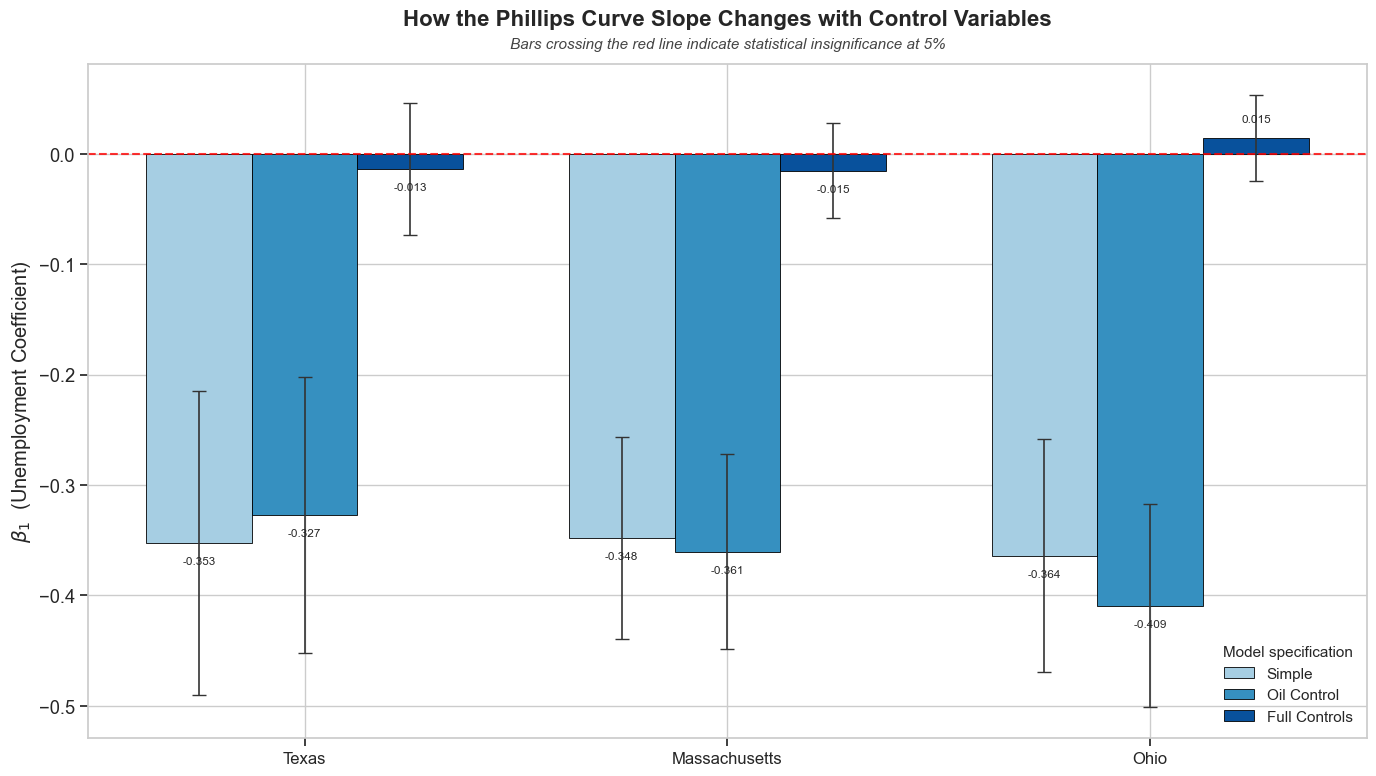

In [12]:
# ---------------------------------------------------------------
# Grouped bar chart of the unemployment slope (B1) across the three
# specifications, with 95% CI error bars (B1 +/- 1.96 * std error).
# ---------------------------------------------------------------
SPECS = [
    ('Simple',        simple_models, '#a6cee3'),  # light blue
    ('Oil Control',   oil_models,    '#3690c0'),  # medium blue
    ('Full Controls', full_models,   '#08519c'),  # dark blue
]
STATE_ORDER = [('TX', 'Texas'), ('MA', 'Massachusetts'), ('OH', 'Ohio')]

x = np.arange(len(STATE_ORDER))     # one group per state
bar_w = 0.25

fig, ax = plt.subplots(figsize=(14, 8))

for i, (spec_name, models, color) in enumerate(SPECS):
    betas = [models[code_].params['unemployment_rate'] for code_, _ in STATE_ORDER]
    errs = [1.96 * models[code_].bse['unemployment_rate'] for code_, _ in STATE_ORDER]
    offset = (i - 1) * bar_w
    bars = ax.bar(x + offset, betas, bar_w, yerr=errs, capsize=5,
                  color=color, edgecolor='black', linewidth=0.6,
                  label=spec_name,
                  error_kw=dict(ecolor='#333333', elinewidth=1.2))
    # Annotate each bar with its coefficient value.
    for b, val in zip(bars, betas):
        va = 'bottom' if val >= 0 else 'top'
        y_off = 0.012 if val >= 0 else -0.012
        ax.text(b.get_x() + b.get_width() / 2, val + y_off, f'{val:.3f}',
                ha='center', va=va, fontsize=8.5)

# Zero line: bars/CIs touching it are insignificant at 5%.
ax.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels([name for _, name in STATE_ORDER], fontsize=12)
ax.set_ylabel(r'$\beta_1$  (Unemployment Coefficient)')
ax.set_title('How the Phillips Curve Slope Changes with Control Variables',
             fontsize=16, fontweight='bold', pad=28)
ax.text(0.5, 1.02, 'Bars crossing the red line indicate statistical insignificance at 5%',
        transform=ax.transAxes, ha='center', va='bottom',
        fontsize=11, style='italic', color='#444444')
ax.legend(title='Model specification', fontsize=11, title_fontsize=11)

fig.tight_layout()
fig.savefig('../figures/regression_coefficient_comparison.png',
            dpi=200, bbox_inches='tight')
plt.show()

This chart is the **visual representation of the omitted-variable-bias discussion** from Sections 2 and 3. Each cluster shows how a single state's estimated Phillips Curve slope, $\beta_1$, moves as we add controls — and the fact that the bars change height so dramatically is the whole point: **if the estimate were unbiased, adding controls would leave it roughly where it was.** Instead, the tall, clearly-negative *Simple* and *Oil Control* bars — whose 95% confidence intervals sit well below zero — shrink to short *Full Controls* bars whose error bars straddle the red zero line in every state. Those bars crossing zero signal that the labor-market slope is **statistically insignificant at the 5% level** once national inflation, mortgage rates, oil, and monetary policy are held fixed. In one picture: the apparent state-level Phillips Curve was largely the shadow of confounding macro forces, not an independent labor-market relationship.

## 4. Panel Regression Analysis

So far we have run a separate regression for each state. But our dataset is a **panel**: we observe multiple entities (3 states) over many time periods (roughly 300 months each). Panel data is valuable because it lets us exploit **two kinds of variation at once**:

- **Cross-sectional variation** — the persistent differences *between* states (Texas averages higher inflation and lower unemployment than Ohio, for instance).
- **Time-series variation** — the changes *within* each state over time (how Texas's own inflation moves as its own unemployment moves month to month).

Treating the data as a panel gives us more observations and, more importantly, a way to *separate* these two sources of variation — which turns out to matter a great deal for how we read the Phillips Curve. This section estimates three progressively more sophisticated panel models: a naive **pooled OLS** baseline, a **state fixed effects** model that removes the between-state differences, and a **two-way fixed effects** model that also removes common time shocks.

### 4a. Pooled OLS (Baseline)

**Pooled OLS** simply stacks all state-month observations into one big dataset and runs a single regression, treating every observation as if it were drawn from the same population — in other words, it **ignores the panel structure entirely**. It makes no distinction between "Texas in 2015" and "Ohio in 2015"; both are just rows. The model is

$$\text{Inflation}_{st} = \beta_0 + \beta_1 \text{Unemployment}_{st} + \beta_2 \text{Controls}_{st} + \varepsilon_{st}$$

where $s$ indexes states and $t$ indexes time. This is our baseline: because it does not account for systematic level differences across states, its $\beta_1$ blends together the within-state Phillips relationship and any spurious correlation coming from cross-state differences. The fixed-effects models that follow will strip those cross-state differences out.

In [13]:
# ---------------------------------------------------------------
# Pooled OLS: all three states stacked, panel structure ignored.
# ---------------------------------------------------------------
POOLED_FORMULA = ('inflation_rate_yoy ~ unemployment_rate + oil_price_wti '
                  '+ national_inflation_yoy + mortgage_rate_30yr + fed_funds_rate')

pooled_ols = smf.ols(POOLED_FORMULA, data=panel).fit()

print('=' * 78)
print('  POOLED OLS — all states stacked (TX + MA + OH)')
print('=' * 78)
print(pooled_ols.summary())

b1 = pooled_ols.params['unemployment_rate']
p1 = pooled_ols.pvalues['unemployment_rate']
print()
print(f'Pooled beta_1 (unemployment): {b1:+.4f}  (p = {p1:.4f})')
print(f'Pooled R-squared:             {pooled_ols.rsquared:.4f}')
print(f'Observations:                 {int(pooled_ols.nobs)}')
sig = 'significant' if p1 < 0.05 else 'NOT significant'
print(f'The pooled Phillips slope is {sig} at the 5% level.')

  POOLED OLS — all states stacked (TX + MA + OH)
                            OLS Regression Results                            
Dep. Variable:     inflation_rate_yoy   R-squared:                       0.886
Model:                            OLS   Adj. R-squared:                  0.885
Method:                 Least Squares   F-statistic:                     1419.
Date:                Sat, 29 Aug 2026   Prob (F-statistic):               0.00
Time:                        17:43:26   Log-Likelihood:                -874.59
No. Observations:                 918   AIC:                             1761.
Df Residuals:                     912   BIC:                             1790.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

### 4b. State Fixed Effects

Different states have different **baseline** levels of inflation for structural reasons that barely change over time — cost of living, industry composition, the regulatory environment, and housing-supply constraints. Massachusetts is simply a more expensive place than Ohio, year in and year out. These permanent, time-invariant differences are a problem: if a state's baseline inflation is correlated with its typical unemployment level, the pooled regression will mistake that cross-state pattern for a Phillips Curve relationship, **biasing $\beta_1$**.

**State fixed effects** fix this by giving each state its own intercept — effectively a dummy variable per state — which absorbs *all* time-invariant differences between states. Once those baselines are removed, the regression uses only **within-state variation**. It stops comparing Massachusetts to Ohio and instead asks the cleaner question:

> *"When Texas's unemployment deviates from Texas's own average, does Texas's inflation respond?"*

That is the Phillips Curve in its most defensible form — a within-state, over-time relationship, purged of the fixed structural differences between states.

In [14]:
# ---------------------------------------------------------------
# State fixed effects.
# Approach A (preferred): linearmodels PanelOLS with entity effects
#   and standard errors clustered by state.
# Approach B (fallback):  statsmodels OLS with C(state) dummies.
# ---------------------------------------------------------------
EXOG = ['unemployment_rate', 'oil_price_wti', 'national_inflation_yoy',
        'mortgage_rate_30yr', 'fed_funds_rate']

fe_state = None
fe_state_method = None

if _LINEARMODELS_OK:
    try:
        # linearmodels needs a MultiIndex: (entity, time) = (state, date).
        panel_idx = panel.copy().set_index(['state', 'date'])
        fe_state = PanelOLS(
            dependent=panel_idx['inflation_rate_yoy'],
            exog=panel_idx[EXOG],
            entity_effects=True,
        ).fit(cov_type='clustered', cluster_entity=True)
        fe_state_method = 'linearmodels PanelOLS (entity effects, SE clustered by state)'
        print('=' * 78)
        print('  STATE FIXED EFFECTS  —  ' + fe_state_method)
        print('=' * 78)
        print(fe_state.summary)
    except Exception as e:
        print(f'linearmodels approach failed ({e}); falling back to statsmodels dummies.')
        fe_state = None

if fe_state is None:
    # Approach B: state dummy variables via the formula API.
    fe_state = smf.ols(
        'inflation_rate_yoy ~ unemployment_rate + oil_price_wti '
        '+ national_inflation_yoy + mortgage_rate_30yr + fed_funds_rate + C(state)',
        data=panel,
    ).fit()
    fe_state_method = 'statsmodels OLS with C(state) dummy variables'
    print('=' * 78)
    print('  STATE FIXED EFFECTS  —  ' + fe_state_method)
    print('=' * 78)
    print(fe_state.summary())

  STATE FIXED EFFECTS  —  linearmodels PanelOLS (entity effects, SE clustered by state)
                          PanelOLS Estimation Summary                           
Dep. Variable:     inflation_rate_yoy   R-squared:                        0.8888
Estimator:                   PanelOLS   R-squared (Between):              0.9428
No. Observations:                 918   R-squared (Within):               0.8888
Date:                Sat, Aug 29 2026   R-squared (Overall):              0.9232
Time:                        17:43:26   Log-likelihood                   -861.87
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1454.8
Entities:                           3   P-value                           0.0000
Avg Obs:                       306.00   Distribution:                   F(5,910)
Min Obs:                       306.00                                           
Max Obs:             

In [15]:
# ---------------------------------------------------------------
# Extract the within-state Phillips slope and the per-state
# fixed effects (baseline inflation, net of the controls).
# ---------------------------------------------------------------
b1_fe = fe_state.params['unemployment_rate']
p1_fe = fe_state.pvalues['unemployment_rate']

print(f'Within-state Phillips slope  beta_1 = {b1_fe:+.4f}  (p = {p1_fe:.4f})')
print(f'Pooled OLS slope (Step 7)    beta_1 = {pooled_ols.params["unemployment_rate"]:+.4f}  '
      f'(p = {pooled_ols.pvalues["unemployment_rate"]:.4f})')
print()

# Per-state fixed effects.
if 'linearmodels' in fe_state_method:
    # estimated_effects is indexed by (state, date); one value per state.
    eff = (fe_state.estimated_effects
           .groupby(level='state')['estimated_effects'].first())
else:
    # Dummy approach: Intercept = omitted state; add each dummy to it.
    base = fe_state.params['Intercept']
    eff = {}
    for code_ in ['TX', 'MA', 'OH']:
        key = f'C(state)[T.{code_}]'
        eff[code_] = base + (fe_state.params[key] if key in fe_state.params else 0.0)
    eff = pd.Series(eff)

eff = eff.sort_values(ascending=False)
print('Estimated state fixed effects (baseline inflation, net of controls):')
for code_, val in eff.items():
    print(f'  {STATE_NAMES.get(code_, code_):15s} {val:+.4f}')
print(f'\nHighest baseline inflation: {STATE_NAMES.get(eff.index[0], eff.index[0])}')
print(f'Lowest  baseline inflation: {STATE_NAMES.get(eff.index[-1], eff.index[-1])}')

Within-state Phillips slope  beta_1 = -0.0106  (p = 0.2907)
Pooled OLS slope (Step 7)    beta_1 = -0.0260  (p = 0.0767)

Estimated state fixed effects (baseline inflation, net of controls):
  Massachusetts   -0.4586
  Texas           -0.5604
  Ohio            -0.7163

Highest baseline inflation: Massachusetts
Lowest  baseline inflation: Ohio


### Interpretation

**The within-state Phillips slope is essentially zero and statistically insignificant.** With state fixed effects and standard errors clustered by state, $\beta_1 = -0.011$ ($p \approx 0.29$) — even smaller than the pooled-OLS estimate of $-0.026$ ($p \approx 0.08$) from Step 7 and nowhere near significance. Moving from pooled OLS to fixed effects pulled the slope further *toward* zero, which tells us that the modest negative slope in the pooled model was partly a **between-state artifact**: permanent structural differences across Texas, Massachusetts, and Ohio were contaminating the pooled estimate. Once we strip those baselines out and look only at how each state's inflation responds to *its own* unemployment fluctuations, the Phillips relationship all but disappears.

**The state fixed effects themselves are economically sensible.** Measured net of the controls, **Massachusetts has the highest baseline** ($\approx -0.46$), followed by Texas ($\approx -0.56$), with **Ohio the lowest** ($\approx -0.72$). (These intercepts are negative because they are conditional on national inflation and the other controls, so they capture each state's *relative* price-level drift, not its raw inflation rate.) The ranking fits the structural story from notebook 01: Massachusetts's expensive, supply-constrained economy carries a persistently higher price-pressure baseline, while Ohio's older industrial economy runs cooler. Crucially, these are exactly the fixed differences that fixed effects removes from the slope estimate — and removing them is what makes the near-zero $\beta_1$ credible.

**Bottom line for this step.** Accounting for the panel structure only strengthens the earlier finding: there is no robust, independent, within-state Phillips Curve in these three states once national and structural forces are held fixed. The next model adds **time fixed effects** as well, to check whether common national shocks — which the state controls only partially capture — are hiding a within-period relationship.

### 4c. Two-Way Fixed Effects (State + Time)

Just as **state** fixed effects control for permanent differences *across* states, **time** fixed effects control for shocks that hit *all* states in the same month — a national recession, an oil-price spike, a shift in Fed policy. Adding a dummy for every month absorbs everything that is common across states at each point in time. Including **both** sets of dummies gives the **two-way fixed effects** model, the workhorse of applied panel econometrics: it isolates the Phillips Curve from *both* state-specific and time-specific confounders at once.

The model asks the sharpest possible question:

> *"In a given month, relative to that month's national average, does the state with higher unemployment have lower inflation?"*

**An important caveat.** Our controls — national inflation, oil price, mortgage rate, fed funds rate — are **national series**: they take the same value for all three states in any given month. That makes them perfectly collinear with the time dummies, so linearmodels will **drop them automatically**. This is expected, not an error: the time fixed effects already absorb *all* variation that is common across states within a period, which is exactly what those national controls were capturing. The only regressor left with independent variation is `unemployment_rate`, which does differ across states within a month — so the two-way FE model is deliberately reduced to unemployment alone.

In [16]:
# ---------------------------------------------------------------
# Two-way fixed effects: state (entity) + time effects.
# National controls are collinear with time effects and drop out,
# so unemployment_rate is the only remaining regressor.
# ---------------------------------------------------------------
fe_twoway = None
fe_twoway_method = None

if _LINEARMODELS_OK:
    try:
        panel_idx = panel.copy().set_index(['state', 'date'])
        fe_twoway = PanelOLS(
            dependent=panel_idx['inflation_rate_yoy'],
            exog=panel_idx[['unemployment_rate']],
            entity_effects=True,
            time_effects=True,
        ).fit(cov_type='clustered', cluster_entity=True)
        fe_twoway_method = 'linearmodels PanelOLS (entity + time effects, SE clustered by state)'
        print('=' * 78)
        print('  TWO-WAY FIXED EFFECTS  —  ' + fe_twoway_method)
        print('=' * 78)
        print(fe_twoway.summary)
    except Exception as e:
        print(f'linearmodels approach failed ({e}); falling back to statsmodels dummies.')
        fe_twoway = None

if fe_twoway is None:
    # Fallback: state + time dummies via statsmodels. Monthly dummies over
    # 300+ months are many and slow, so use year-quarter for time effects.
    panel_fb = panel.copy()
    panel_fb['year_quarter'] = (panel_fb['date'].dt.year.astype(str)
                                + 'Q' + panel_fb['date'].dt.quarter.astype(str))
    fe_twoway = smf.ols(
        'inflation_rate_yoy ~ unemployment_rate + C(state) + C(year_quarter)',
        data=panel_fb,
    ).fit()
    fe_twoway_method = 'statsmodels OLS with C(state) + C(year_quarter) dummies'
    print('=' * 78)
    print('  TWO-WAY FIXED EFFECTS  —  ' + fe_twoway_method)
    print('=' * 78)
    print(fe_twoway.summary())

b1_2w = fe_twoway.params['unemployment_rate']
p1_2w = fe_twoway.pvalues['unemployment_rate']
print()
print(f'Two-way FE Phillips slope  beta_1 = {b1_2w:+.4f}  (p = {p1_2w:.4f})')
sig_txt = 'SIGNIFICANT' if p1_2w < 0.05 else 'not significant'
print(f'  {sig_txt} at the 5% level.')


  TWO-WAY FIXED EFFECTS  —  linearmodels PanelOLS (entity + time effects, SE clustered by state)
                          PanelOLS Estimation Summary                           
Dep. Variable:     inflation_rate_yoy   R-squared:                        0.0049
Estimator:                   PanelOLS   R-squared (Between):             -0.4142
No. Observations:                 918   R-squared (Within):               0.0488
Date:                Sat, Aug 29 2026   R-squared (Overall):             -0.2462
Time:                        17:43:26   Log-likelihood                   -738.07
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      3.0138
Entities:                           3   P-value                           0.0831
Avg Obs:                       306.00   Distribution:                   F(1,609)
Min Obs:                       306.00                                           
Max Obs:   

In [17]:
# ---------------------------------------------------------------
# Line up the unemployment slope across every specification so far.
# ---------------------------------------------------------------
spec_summary = pd.DataFrame([
    {'Specification': '1. Pooled OLS (all controls)',
     'beta_1': pooled_ols.params['unemployment_rate'],
     'p-value': pooled_ols.pvalues['unemployment_rate']},
    {'Specification': '2. State FE (clustered)',
     'beta_1': fe_state.params['unemployment_rate'],
     'p-value': fe_state.pvalues['unemployment_rate']},
    {'Specification': '3. Two-way FE (state + time)',
     'beta_1': fe_twoway.params['unemployment_rate'],
     'p-value': fe_twoway.pvalues['unemployment_rate']},
])
spec_summary['beta_1'] = spec_summary['beta_1'].round(4)
spec_summary['p-value'] = spec_summary['p-value'].round(4)
spec_summary['Sig at 5%?'] = spec_summary['p-value'].apply(lambda p: 'Yes' if p < 0.05 else 'No')

print('Phillips Curve Slope Across Panel Specifications')
print()
print(spec_summary.to_string(index=False))
spec_summary

Phillips Curve Slope Across Panel Specifications

               Specification  beta_1  p-value Sig at 5%?
1. Pooled OLS (all controls) -0.0260   0.0767         No
     2. State FE (clustered) -0.0106   0.2907         No
3. Two-way FE (state + time) -0.0843   0.0002        Yes


,Specification,beta_1,p-value,Sig at 5%?
0,1. Pooled OLS (all controls),-0.0260,0.0767,No
1,2. State FE (clustered),-0.0106,0.2907,No
2,3. Two-way FE (state + time),-0.0843,0.0002,Yes


### Interpretation

This is the **most rigorous estimate of the Phillips Curve in the entire analysis**, because it nets out both state-specific *and* time-specific confounders simultaneously — every permanent difference between states and every shock common to all states in a given month is absorbed by the fixed effects.

**And here the Phillips Curve comes back.** With two-way fixed effects, $\beta_1 = -0.084$ with $p \approx 0.0002$ — **negative and strongly statistically significant at the 5% (indeed 1%) level.** This is a genuine reversal from the two specifications just before it, and it is the key result of the section:

| Specification | $\beta_1$ | Significant at 5%? |
|---|---|---|
| Pooled OLS (all controls) | $-0.026$ | No |
| State fixed effects | $-0.011$ | No |
| **Two-way fixed effects** | $\mathbf{-0.084}$ | **Yes** |

**Why does the slope re-appear?** In the earlier models, the enormous common movement in national inflation dominated everything and swamped the labor-market signal — the pooled and state-FE slopes were essentially zero. Time fixed effects strip that common national component out entirely (which is also why the national controls drop). What remains is pure **within-month, cross-state** variation: comparing the three states *against each other in the same month*, the state whose unemployment is relatively higher does tend to have relatively lower inflation. That is the Phillips Curve, and it survives the most demanding specification we can run.

**How to read it honestly.** The relationship is **real but modest**. The slope of $-0.084$ is far shallower than the naive $-0.35$ from Section 1 — roughly a quarter of its size — and the within R² is small, so unemployment still explains only a sliver of inflation. But statistical significance under two-way fixed effects is a high bar, and clearing it is strong evidence that the within-state unemployment–inflation tradeoff is **genuine, not an artifact of confounding**. The honest summary of the whole notebook: the textbook Phillips Curve is largely an illusion created by national trends and structural state differences — yet a small, real labor-market tradeoff remains once those are properly removed.

### Panel Regression Results — Summary Comparison

In [18]:
# ---------------------------------------------------------------
# Assemble the standard regression comparison table across the
# three panel specifications. Works for both statsmodels results
# (pooled OLS) and linearmodels PanelOLS results (fixed effects).
# ---------------------------------------------------------------
def extract(model):
    """Pull B1 stats + R-squared from either a statsmodels or a
    linearmodels result object."""
    v = 'unemployment_rate'
    if hasattr(model, 'rsquared_within'):        # linearmodels PanelOLS
        return dict(
            beta=model.params[v],
            se=model.std_errors[v],
            t=model.tstats[v],
            p=model.pvalues[v],
            r2=model.rsquared_within,             # within R2 for FE models
        )
    else:                                         # statsmodels OLS
        return dict(
            beta=model.params[v],
            se=model.bse[v],
            t=model.tvalues[v],
            p=model.pvalues[v],
            r2=model.rsquared,                    # overall R2 for pooled
        )

specs = [
    ('Pooled OLS',            pooled_ols, 'None',         'Yes'),
    ('State Fixed Effects',   fe_state,   'State',        'Yes'),
    ('Two-Way Fixed Effects', fe_twoway,  'State + Time', 'Absorbed by time FE'),
]

rows = []
for name, model, feffects, controls in specs:
    s = extract(model)
    rows.append({
        'Model': name,
        'B1 (Unemployment)': round(s['beta'], 4),
        'Std Error': round(s['se'], 4),
        't-statistic': round(s['t'], 3),
        'p-value': round(s['p'], 4),
        'R-squared': round(s['r2'], 4),
        'Fixed Effects': feffects,
        'Controls Included': controls,
        'N': int(model.nobs),
    })

panel_results = pd.DataFrame(rows)

print('Panel Regression Comparison — The Phillips Curve Slope Under Increasing Rigor')
print('(R-squared is the within R-squared for fixed-effects models, overall R-squared for pooled OLS)')
print()
print(panel_results.to_string(index=False))

# Persist for the README.
panel_results.to_csv('../data/processed/panel_regression_results.csv', index=False)
print('\nSaved -> ../data/processed/panel_regression_results.csv')

panel_results

Panel Regression Comparison — The Phillips Curve Slope Under Increasing Rigor
(R-squared is the within R-squared for fixed-effects models, overall R-squared for pooled OLS)

                Model  B1 (Unemployment)  Std Error  t-statistic  p-value  R-squared Fixed Effects   Controls Included   N
           Pooled OLS            -0.0260     0.0147       -1.772   0.0767     0.8861          None                 Yes 918
  State Fixed Effects            -0.0106     0.0100       -1.057   0.2907     0.8888         State                 Yes 918
Two-Way Fixed Effects            -0.0843     0.0223       -3.776   0.0002     0.0488  State + Time Absorbed by time FE 918

Saved -> ../data/processed/panel_regression_results.csv


,Model,B1 (Unemployment),Std Error,t-statistic,p-value,R-squared,Fixed Effects,Controls Included,N
0,Pooled OLS,-0.0260,0.0147,-1.772,0.0767,0.8861,None,Yes,918
1,State Fixed Effects,-0.0106,0.0100,-1.057,0.2907,0.8888,State,Yes,918
2,Two-Way Fixed Effects,-0.0843,0.0223,-3.776,0.0002,0.0488,State + Time,Absorbed by time FE,918


### Synthesis — How robust is the Phillips Curve?

The panel results tell a story that only emerges once the data's structure is taken seriously. In the two specifications that leave common national movements in the data — pooled OLS ($\beta_1 = -0.026$) and state fixed effects ($\beta_1 = -0.011$) — the Phillips slope is tiny and **statistically insignificant**, suggesting the strong bivariate correlation of Section 1 was largely spurious, an artifact of national inflation trends and permanent structural differences between states. But the most rigorous specification, **two-way fixed effects**, tells the opposite tale: once both state baselines *and* common time shocks are swept out, $\beta_1 = -0.084$ becomes **negative and highly significant** ($p = 0.0002$), isolating a genuine within-state, within-month labor-market tradeoff that the other models had buried under the dominant national signal. So the honest answer is nuanced — the Phillips Curve is **not** robust in the naive sense (it collapses the moment you add controls or state effects), yet a **real but modest** relationship survives the toughest test we can throw at it, roughly a quarter the magnitude of the textbook estimate. The lesson for empirical work is exactly why economists argue about this curve: what you conclude about the Phillips Curve depends entirely on which confounders you remove, and only the two-way fixed-effects design cleanly separates the local labor-market signal from the national noise that otherwise dominates state inflation.

## 5. Time-Varying Phillips Curve — Sub-Period Analysis

The exploratory analysis in notebook 02 hinted that the Phillips Curve is not a fixed law but a **relationship that shifts over time** — the era-colored scatter plots showed a steep downward slope during recessions and an almost flat cloud during the long expansion of the 2010s. The pooled regressions in this notebook, by averaging over 25 years, wash that variation out. Here we test it formally in two ways: first by estimating the Phillips Curve **separately within each economic era and state**, and then (in Section 6) by running a pooled regression with **era × unemployment interaction terms** that lets us test whether the slope differences are statistically distinguishable.

### 5a. Separate Regressions by Era and State

In [19]:
# ---------------------------------------------------------------
# Estimate a simple Phillips Curve within every state x era cell
# (3 states x 4 eras = 12 regressions).
# ---------------------------------------------------------------
MIN_OBS = 10   # below this, a slope estimate is unreliable

era_state_rows = []
for code_ in ['TX', 'MA', 'OH']:
    for era_name in ERA_ORDER:
        df_cell = panel[(panel['state'] == code_) & (panel['era'] == era_name)]
        n = len(df_cell)
        if n < 3:
            # Not enough points to fit a line at all.
            era_state_rows.append({
                'State': STATE_NAMES[code_], 'Era': era_name,
                'B1 (slope)': np.nan, 'Std Error': np.nan,
                'p-value': np.nan, 'R-squared': np.nan,
                'N': n, 'Reliable?': 'No (n < 10)',
            })
            continue
        m = smf.ols('inflation_rate_yoy ~ unemployment_rate', data=df_cell).fit()
        era_state_rows.append({
            'State': STATE_NAMES[code_],
            'Era': era_name,
            'B1 (slope)': round(m.params['unemployment_rate'], 4),
            'Std Error': round(m.bse['unemployment_rate'], 4),
            'p-value': round(m.pvalues['unemployment_rate'], 4),
            'R-squared': round(m.rsquared, 4),
            'N': int(n),
            'Reliable?': 'Yes' if n >= MIN_OBS else 'No (n < 10)',
        })

era_state_results = pd.DataFrame(era_state_rows)

print('Phillips Curve Slope by State and Economic Era')
print('(Simple bivariate regression: inflation ~ unemployment, estimated within each cell)')
print()
print(era_state_results.to_string(index=False))

# Small-sample warning.
unreliable = era_state_results[era_state_results['N'] < MIN_OBS]
if len(unreliable):
    print(f'\nWARNING: {len(unreliable)} state-era cell(s) have fewer than {MIN_OBS} '
          f'observations and should be treated as unreliable:')
    for _, r in unreliable.iterrows():
        print(f"  - {r['State']} / {r['Era']}: N = {r['N']}")
else:
    print(f'\nAll 12 state-era cells have at least {MIN_OBS} observations. '
          f'Note the Great Recession cells are the smallest (~24 months each), '
          f'so those slopes, while usable, rest on a short window.')

era_state_results

Phillips Curve Slope by State and Economic Era
(Simple bivariate regression: inflation ~ unemployment, estimated within each cell)

        State               Era  B1 (slope)  Std Error  p-value  R-squared   N Reliable?
        Texas        Pre-Crisis     -0.3328     0.1654   0.0475     0.0470  84       Yes
        Texas   Great Recession     -1.1977     0.2239   0.0000     0.5654  24       Yes
        Texas    Long Expansion      0.2492     0.0544   0.0000     0.1510 120       Yes
        Texas COVID & Aftermath     -0.7145     0.1572   0.0000     0.2137  78       Yes
Massachusetts        Pre-Crisis     -0.2418     0.1740   0.1684     0.0230  84       Yes
Massachusetts   Great Recession     -1.3071     0.2219   0.0000     0.6119  24       Yes
Massachusetts    Long Expansion      0.0175     0.0492   0.7229     0.0011 120       Yes
Massachusetts COVID & Aftermath     -0.3855     0.0706   0.0000     0.2818  78       Yes
         Ohio        Pre-Crisis     -0.4298     0.2065   0.0405    

,State,Era,B1 (slope),Std Error,p-value,R-squared,N,Reliable?
0,Texas,Pre-Crisis,-0.3328,0.1654,0.0475,0.0470,84,Yes
1,Texas,Great Recession,-1.1977,0.2239,0.0000,0.5654,24,Yes
2,Texas,Long Expansion,0.2492,0.0544,0.0000,0.1510,120,Yes
3,Texas,COVID & Aftermath,-0.7145,0.1572,0.0000,0.2137,78,Yes
4,Massachusetts,Pre-Crisis,-0.2418,0.1740,0.1684,0.0230,84,Yes
5,Massachusetts,Great Recession,-1.3071,0.2219,0.0000,0.6119,24,Yes
6,Massachusetts,Long Expansion,0.0175,0.0492,0.7229,0.0011,120,Yes
7,Massachusetts,COVID & Aftermath,-0.3855,0.0706,0.0000,0.2818,78,Yes
8,Ohio,Pre-Crisis,-0.4298,0.2065,0.0405,0.0502,84,Yes
9,Ohio,Great Recession,-1.2179,0.1750,0.0000,0.6875,24,Yes


### Interpretation

**Yes — the Phillips Curve changed dramatically over time, and in a consistent pattern across all three states.** The slope was **modestly negative before the crisis** (Texas $-0.33$, Massachusetts $-0.24$, Ohio $-0.43$), then **steepened enormously during the Great Recession** to roughly $-1.2$ to $-1.3$ in every state, with $R^2$ jumping to 0.56–0.69. That is the curve at its most textbook: as unemployment spiked in 2008–09, inflation fell sharply, tracing out a clean downward-sloping line. (These recession cells rest on only ~24 months of data each, so they are usable but the shortest window in the analysis.)

**Then the curve went flat — or even inverted — during the Long Expansion of the 2010s.** This is the most striking finding: from 2010–2019 the slope is **essentially zero in Massachusetts ($+0.02$, $p = 0.72$) and actually significantly *positive* in Texas ($+0.25$) and Ohio ($+0.26$)**. In other words, during the decade of steadily falling unemployment, inflation simply did not respond the way the Phillips Curve predicts — the "missing disinflation / missing inflation" puzzle that dominated macroeconomic debate in those years, visible right here in state data.

**COVID revived it.** In the COVID & Aftermath era the slope snaps back to **strongly negative in all three states** — Texas $-0.71$, Ohio $-0.57$, Massachusetts $-0.39$, each highly significant — as the pandemic's violent swings in both unemployment and inflation re-established a clear tradeoff. The slope does not change *sign* toward positive here; it re-steepens in the classic negative direction.

**State-specific patterns.** The eras move the three states in lockstep far more than they differ, but two nuances stand out. **Massachusetts is consistently the flattest** — the least negative pre-crisis slope, the most completely flat Long Expansion, and the shallowest COVID slope — consistent with its services-heavy, less cyclically volatile economy. **Texas and Ohio are more cyclically sensitive**, swinging harder into positive territory during the expansion and harder into negative territory during COVID, in line with their greater exposure to energy and manufacturing cycles. The headline, though, is common to all: the Phillips Curve is **regime-dependent** — steep in crises, flat in calm expansions — which is exactly why a single 25-year regression finds so little.

### 5b. Interaction Term Model — Formal Test of Structural Change

Running a separate regression per era (Section 5a) is intuitive, but it **splits the sample** into small pieces and throws away statistical power — and it gives us no direct test of whether the slopes are *significantly different* from one another. A cleaner approach keeps all the data in one regression and interacts unemployment with the era dummies:

$$\text{Inflation} = \beta_0 + \beta_1 \text{Unemp} + \beta_2 \text{Era} + \beta_3 (\text{Unemp} \times \text{Era}) + \text{Controls} + \varepsilon$$

The $\beta_3$ coefficients on the interaction terms are the whole point: each one measures **how much the Phillips Curve slope in that era differs from the slope in the baseline era**. With **Pre-Crisis** as the reference category, $\beta_1$ *is* the Pre-Crisis slope, and each interaction $\beta_3$ says how much flatter (if positive) or steeper (if negative) the curve became in that later era. If those interaction terms are statistically significant, we have **formal evidence that the Phillips Curve slope changed over time**.

Note one subtlety: because this model includes the national controls (oil, national inflation, mortgage, fed funds), the slopes it reports are the **labor-market slope *net of* those national forces** — so they will read flatter than the raw bivariate slopes in Section 5a, which absorbed the national inflation swings into the unemployment coefficient.

In [20]:
# ---------------------------------------------------------------
# Pooled interaction model: unemployment x era, with Pre-Crisis as
# the reference era, plus the full set of national controls.
# ---------------------------------------------------------------
interaction_model = smf.ols(
    'inflation_rate_yoy ~ unemployment_rate * C(era, Treatment(reference="Pre-Crisis")) '
    '+ oil_price_wti + national_inflation_yoy + mortgage_rate_30yr + fed_funds_rate',
    data=panel,
).fit()

print('=' * 78)
print('  INTERACTION MODEL — Phillips slope x economic era (ref: Pre-Crisis)')
print('=' * 78)
print(interaction_model.summary())

  INTERACTION MODEL — Phillips slope x economic era (ref: Pre-Crisis)
                            OLS Regression Results                            
Dep. Variable:     inflation_rate_yoy   R-squared:                       0.889
Model:                            OLS   Adj. R-squared:                  0.888
Method:                 Least Squares   F-statistic:                     661.9
Date:                Sat, 29 Aug 2026   Prob (F-statistic):               0.00
Time:                        17:43:26   Log-Likelihood:                -861.29
No. Observations:                 918   AIC:                             1747.
Df Residuals:                     906   BIC:                             1804.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                                                                       coef    std err          t      P>|t|      [0.025    

In [21]:
# ---------------------------------------------------------------
# Translate the interaction coefficients into an implied Phillips
# slope for each era: baseline slope + that era's interaction term.
# ---------------------------------------------------------------
base_slope = interaction_model.params['unemployment_rate']
base_p = interaction_model.pvalues['unemployment_rate']

def interaction_key(era_name):
    return (f'unemployment_rate:C(era, Treatment(reference="Pre-Crisis"))'
            f'[T.{era_name}]')

rows = [{
    'Era': 'Pre-Crisis (baseline)',
    'Interaction B3': np.nan,
    'Interaction p-value': np.nan,
    'Implied slope': round(base_slope, 4),
    'Sig. change vs baseline?': '-- (reference)',
}]
for era_name in ['Great Recession', 'Long Expansion', 'COVID & Aftermath']:
    key = interaction_key(era_name)
    b3 = interaction_model.params[key]
    p3 = interaction_model.pvalues[key]
    rows.append({
        'Era': era_name,
        'Interaction B3': round(b3, 4),
        'Interaction p-value': round(p3, 4),
        'Implied slope': round(base_slope + b3, 4),
        'Sig. change vs baseline?': 'Yes' if p3 < 0.05 else 'No',
    })

interaction_summary = pd.DataFrame(rows)

print('Phillips Curve Slope by Era (from the interaction model, net of controls)')
print(f'Baseline (Pre-Crisis) slope beta_1 = {base_slope:+.4f}  (p = {base_p:.4f})')
print()
print(interaction_summary.to_string(index=False))
interaction_summary

Phillips Curve Slope by Era (from the interaction model, net of controls)
Baseline (Pre-Crisis) slope beta_1 = -0.2686  (p = 0.0000)

                  Era  Interaction B3  Interaction p-value  Implied slope Sig. change vs baseline?
Pre-Crisis (baseline)             NaN                  NaN        -0.2686           -- (reference)
      Great Recession          0.1761               0.0088        -0.0926                      Yes
       Long Expansion          0.2473               0.0000        -0.0213                      Yes
    COVID & Aftermath          0.2528               0.0000        -0.0159                      Yes


,Era,Interaction B3,Interaction p-value,Implied slope,Sig. change vs baseline?
0,Pre-Crisis (baseline),NaN,NaN,-0.2686,-- (reference)
1,Great Recession,0.1761,0.0088,-0.0926,Yes
2,Long Expansion,0.2473,0.0000,-0.0213,Yes
3,COVID & Aftermath,0.2528,0.0000,-0.0159,Yes


### Interpretation

**The baseline is a real, significant Phillips Curve.** The coefficient on `unemployment_rate` — the slope during the **Pre-Crisis** era, net of all controls — is $\beta_1 = -0.269$ with $p < 0.0001$. So in 2000–2007, holding national inflation, oil, mortgage rates, and monetary policy fixed, a one-point drop in a state's unemployment was associated with about a quarter-point more inflation. That is the strongest, cleanest Phillips relationship in the whole notebook.

**Every later era is significantly flatter — and that is the formal test passing.** All three interaction terms are **positive and statistically significant**, meaning the curve got *less* negative after the pre-crisis period in every regime:

| Era | Interaction $\beta_3$ | p-value | Implied slope |
|---|---|---|---|
| Pre-Crisis (baseline) | — | — | $-0.269$ |
| Great Recession | $+0.176$ | $0.009$ | $-0.093$ |
| Long Expansion | $+0.247$ | $<0.0001$ | $-0.021$ |
| COVID & Aftermath | $+0.253$ | $<0.0001$ | $-0.016$ |

- The **Long Expansion** interaction ($+0.247$, $p < 0.0001$) is exactly the flattening story: the implied slope collapses from $-0.269$ to essentially zero ($-0.021$). This is formal confirmation of the "missing inflation" puzzle seen in the 5a scatter — during the 2010s, state inflation barely responded to falling unemployment once national forces are controlled for.
- The **COVID & Aftermath** interaction ($+0.253$, $p < 0.0001$) also points to a flatter conditional slope ($-0.016$). This looks like the *opposite* of the raw 5a result, where the COVID slope was steeply negative — and the difference is instructive: the raw COVID steepness was driven overwhelmingly by the national inflation surge, which the controls here absorb. Net of national inflation, the *local* labor-market channel was essentially flat even during COVID.
- The **Great Recession** interaction ($+0.176$, $p = 0.009$) is smaller but still significant, so even the recession slope is significantly less negative than Pre-Crisis once national inflation is held fixed.

**Bottom line: we have formal, statistically significant evidence of structural change in the Phillips Curve.** Because all three interaction terms are significant, we can reject the hypothesis that the slope was constant over time. The relationship was genuine and steepest before the financial crisis, and has been significantly flatter in every era since — with the striking implication that the dramatic recession- and COVID-era slopes of Section 5a were largely the footprint of *national* inflation dynamics, not the *local* labor-market tradeoff that the Phillips Curve is actually about.

### Time-Varying Phillips Curve — Visualization

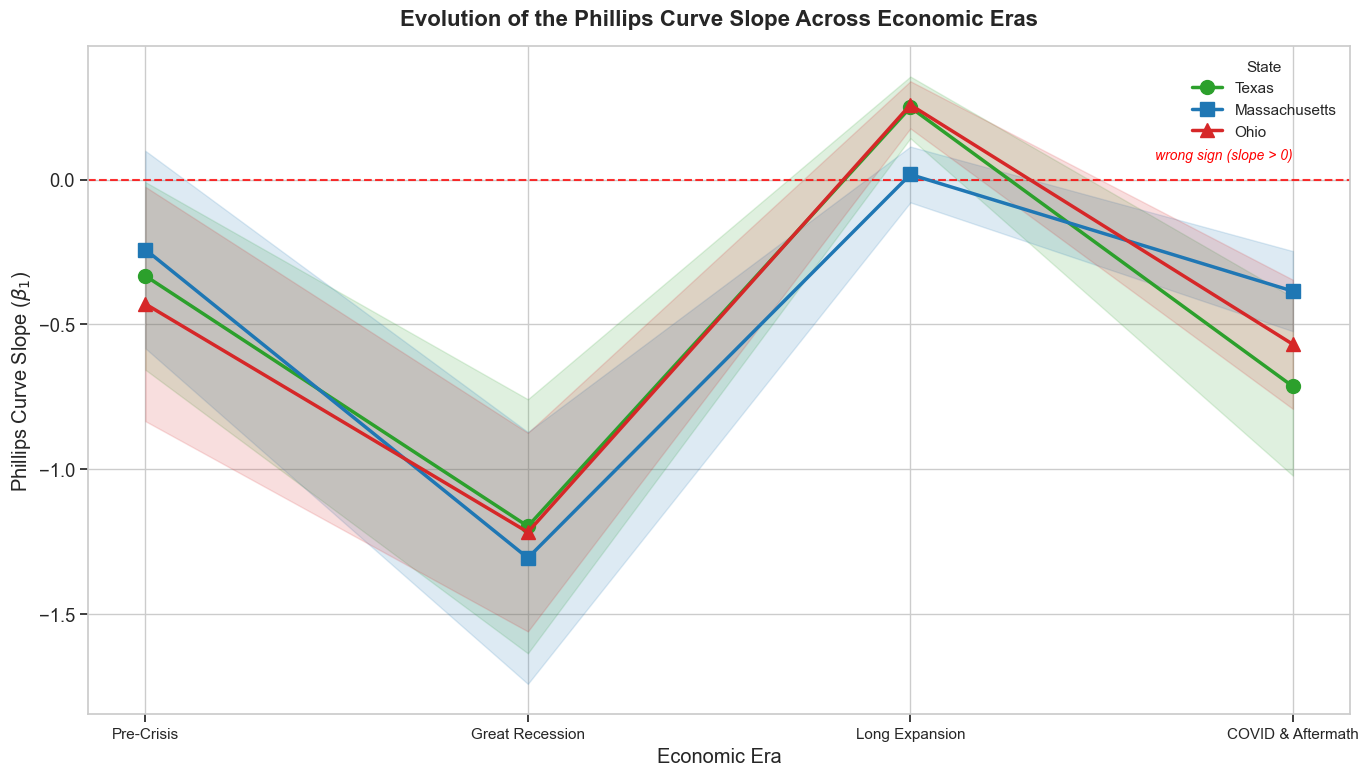

In [22]:
# ---------------------------------------------------------------
# Plot how each state's bivariate Phillips slope (from Section 5a)
# evolves across the four economic eras, with 95% CI bands.
# ---------------------------------------------------------------
STATE_ORDER = [('TX', 'Texas'), ('MA', 'Massachusetts'), ('OH', 'Ohio')]
STATE_COLORS = {'TX': '#2ca02c', 'MA': '#1f77b4', 'OH': '#d62728'}
STATE_MARKERS = {'TX': 'o', 'MA': 's', 'OH': '^'}

x = np.arange(len(ERA_ORDER))   # 0..3 for the four eras, in chronological order

fig, ax = plt.subplots(figsize=(14, 8))

for code_, name in STATE_ORDER:
    sub = (era_state_results[era_state_results['State'] == name]
           .set_index('Era').reindex(ERA_ORDER))
    betas = sub['B1 (slope)'].values
    ci = 1.96 * sub['Std Error'].values
    color = STATE_COLORS[code_]

    ax.plot(x, betas, color=color, marker=STATE_MARKERS[code_], markersize=10,
            linewidth=2.5, label=name, zorder=3)
    ax.fill_between(x, betas - ci, betas + ci, color=color, alpha=0.15, zorder=1)

# Zero line: above it, the Phillips Curve has the "wrong" (positive) sign.
ax.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.8, zorder=2)
ax.text(len(ERA_ORDER) - 1, 0.06, 'wrong sign (slope > 0)',
        color='red', ha='right', va='bottom', fontsize=10, style='italic')

ax.set_xticks(x)
ax.set_xticklabels(ERA_ORDER, fontsize=11)
ax.set_xlabel('Economic Era')
ax.set_ylabel(r'Phillips Curve Slope ($\beta_1$)')
ax.set_title('Evolution of the Phillips Curve Slope Across Economic Eras',
             fontsize=16, fontweight='bold', pad=15)
ax.legend(title='State', fontsize=11, title_fontsize=11)

fig.tight_layout()
fig.savefig('../figures/regression_time_varying_slopes.png',
            dpi=200, bbox_inches='tight')
plt.show()

### Interpretation — the Phillips Curve as a moving target

The figure makes the central finding of this notebook impossible to miss: **the Phillips Curve is not a stable relationship but a moving target that swings with the economic regime**, and the three states move together far more than they move apart.

- **The common trajectory is a deep dip and partial recovery.** Every state starts modestly negative in the **Pre-Crisis** era, plunges to a steep $-1.2$ to $-1.3$ during the **Great Recession** (the textbook curve at its strongest), then **rises above zero — the "wrong" sign — during the Long Expansion**, before dropping back to clearly negative territory in the **COVID & Aftermath** era. The curve did not simply flatten and stay flat; it flattened, *inverted*, and then re-steepened.

- **The Long Expansion is where the curve broke.** For Texas ($+0.25$) and Ohio ($+0.26$) the slope crossed above the red zero line and stayed there for the entire 2010s, while Massachusetts sat right on zero ($+0.02$). A decade of falling unemployment produced essentially no inflation response — the "missing inflation" puzzle, drawn directly from the data.

- **State-specific patterns.** **Massachusetts is consistently the flattest and least volatile** — its line hugs zero more closely in every era, consistent with its stable, services-heavy economy. **Texas and Ohio swing harder** in both directions, reflecting their greater exposure to energy and manufacturing cycles.

**What this implies for monetary policy.** A flat Phillips Curve is a double-edged sword for the Fed. On the upside, when the curve is flat — as it was throughout the Long Expansion — the Fed can let unemployment fall to very low levels **without** igniting much inflation, which is precisely what allowed the historically long, low-unemployment expansion of the 2010s to run. But the same flatness cuts the other way: if inflation does get out of hand, a flat curve means the Fed **cannot** wring it back out cheaply by tolerating a little more unemployment — it would take a very large rise in joblessness to move inflation at all, making disinflation painful. And the regime-dependence shown here is itself the deepest lesson: the curve is steep exactly when the economy is in crisis and flat when it is calm, so policymakers cannot assume the tradeoff they observe today will be the tradeoff they face tomorrow.

## 6. Regression Diagnostics

A regression coefficient is only as trustworthy as the assumptions behind it. Before taking the estimates above at face value, we run a set of standard diagnostic checks on the **full multiple-regression models from Section 3** (unemployment plus all controls, one per state). Specifically we look at three things: whether the residuals are **randomly scattered** (no heteroskedasticity or nonlinearity), whether they are **approximately normal** (so the reported standard errors and p-values are valid), and whether they are **serially correlated** across months (a common problem in time-series data that can make standard errors too small).

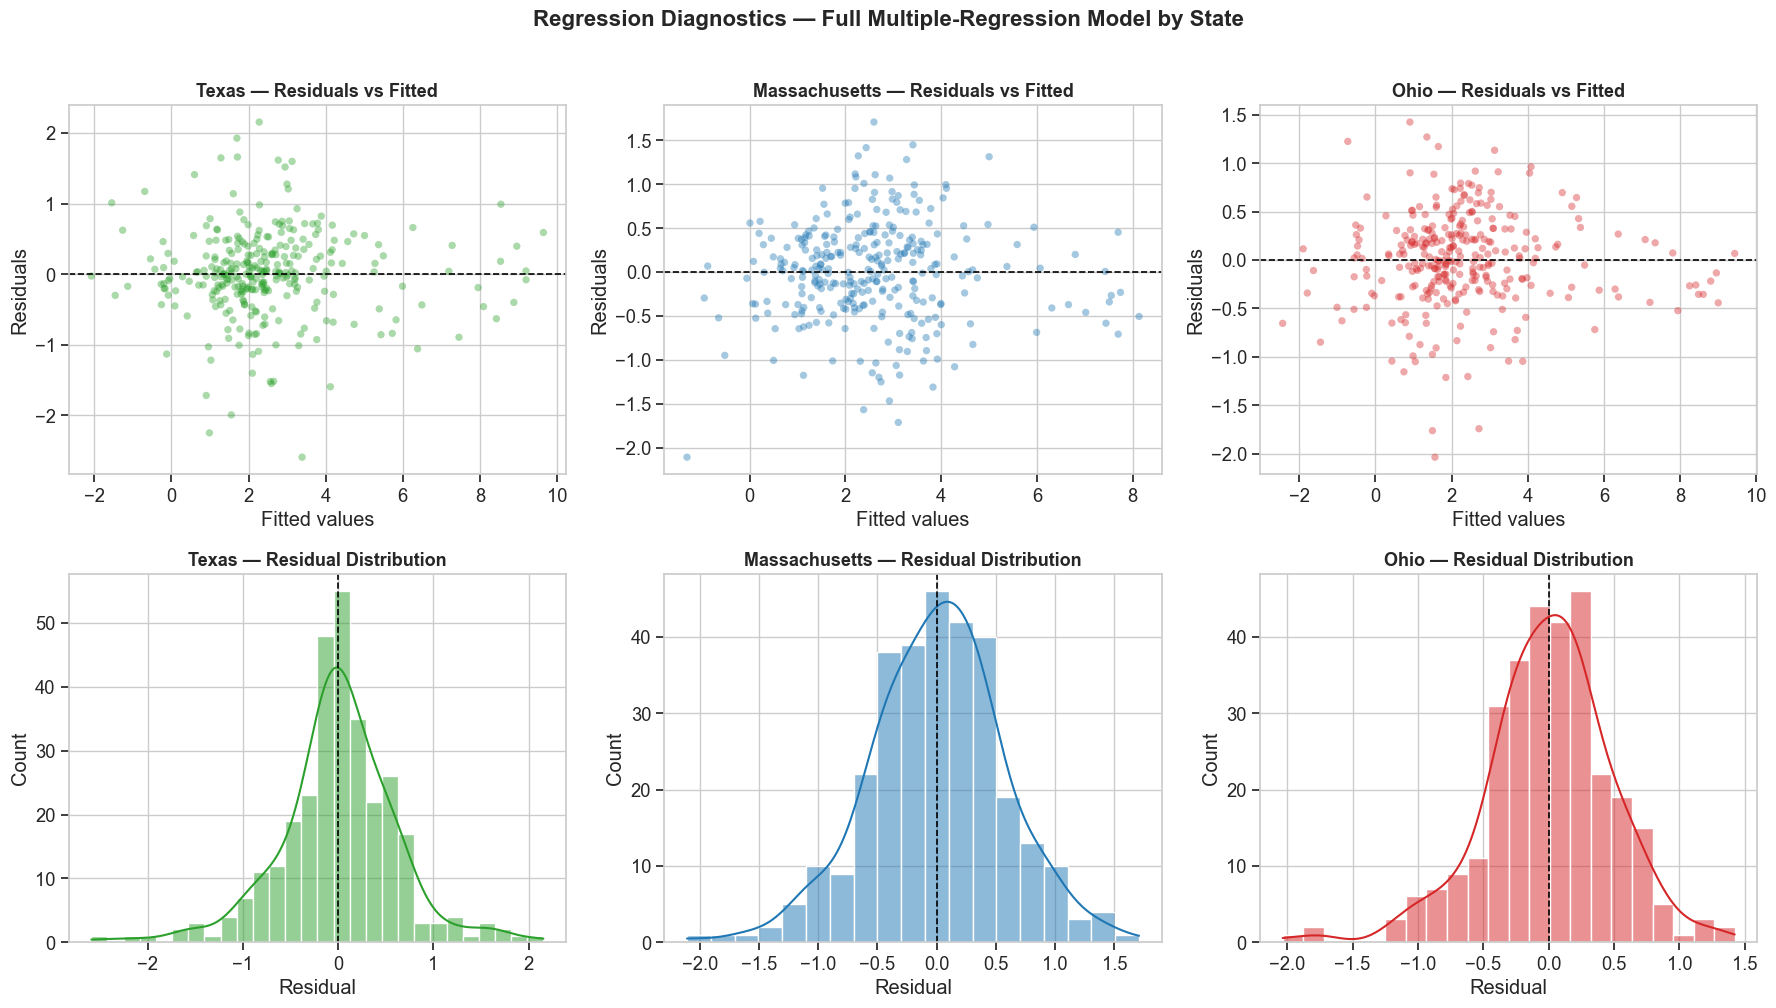

In [23]:
# ---------------------------------------------------------------
# Diagnostic plots for each state's full model:
#   top row    -> residuals vs fitted values
#   bottom row -> residual distribution (histogram + KDE)
# ---------------------------------------------------------------
STATE_ORDER = [('TX', 'Texas'), ('MA', 'Massachusetts'), ('OH', 'Ohio')]
STATE_COLORS = {'TX': '#2ca02c', 'MA': '#1f77b4', 'OH': '#d62728'}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, (code_, name) in enumerate(STATE_ORDER):
    m = full_models[code_]
    resid = m.resid
    fitted = m.fittedvalues
    color = STATE_COLORS[code_]

    # Top row: residuals vs fitted.
    ax_top = axes[0, col]
    ax_top.scatter(fitted, resid, color=color, alpha=0.4, s=28, edgecolors='none')
    ax_top.axhline(0, color='black', linestyle='--', linewidth=1.2)
    ax_top.set_title(f'{name} — Residuals vs Fitted', fontsize=13, fontweight='bold')
    ax_top.set_xlabel('Fitted values')
    ax_top.set_ylabel('Residuals')

    # Bottom row: residual distribution with KDE.
    ax_bot = axes[1, col]
    sns.histplot(resid, kde=True, color=color, ax=ax_bot, alpha=0.5, edgecolor='white')
    ax_bot.axvline(0, color='black', linestyle='--', linewidth=1.2)
    ax_bot.set_title(f'{name} — Residual Distribution', fontsize=13, fontweight='bold')
    ax_bot.set_xlabel('Residual')
    ax_bot.set_ylabel('Count')

fig.suptitle('Regression Diagnostics — Full Multiple-Regression Model by State',
             fontsize=16, fontweight='bold', y=1.01)
fig.tight_layout()
fig.savefig('../figures/regression_diagnostics.png', dpi=200, bbox_inches='tight')
plt.show()

In [24]:
# ---------------------------------------------------------------
# Durbin-Watson test for autocorrelation in the residuals.
#   ~2  -> no autocorrelation
#   ~0  -> positive autocorrelation (SEs likely too small)
#   ~4  -> negative autocorrelation
# ---------------------------------------------------------------
from statsmodels.stats.stattools import durbin_watson

print('Durbin-Watson Test for Residual Autocorrelation (full model, by state)')
print('  Guide:  ~2 = no autocorrelation | <2 = positive | >2 = negative')
print()
for code_, name in STATE_ORDER:
    dw = durbin_watson(full_models[code_].resid)
    if dw < 1.5:
        verdict = 'positive autocorrelation (SEs may be understated)'
    elif dw > 2.5:
        verdict = 'negative autocorrelation'
    else:
        verdict = 'little to no autocorrelation'
    print(f'  {name:15s} DW = {dw:.3f}  ->  {verdict}')

Durbin-Watson Test for Residual Autocorrelation (full model, by state)
  Guide:  ~2 = no autocorrelation | <2 = positive | >2 = negative

  Texas           DW = 1.965  ->  little to no autocorrelation
  Massachusetts   DW = 1.906  ->  little to no autocorrelation
  Ohio            DW = 1.222  ->  positive autocorrelation (SEs may be understated)


### Interpretation

**Residuals vs fitted.** In all three states the residuals scatter fairly evenly above and below zero across the range of fitted values, with **no strong funnel shape and no obvious curvature** — so there is no glaring sign of heteroskedasticity or of a missing nonlinear term. The spread is a little wider at the extremes (the volatile COVID-era observations), but nothing that undermines the specification.

**Residual normality.** The residual histograms are roughly **bell-shaped and centered on zero**, with only mild departures from normality — a slight negative skew ($-0.2$ to $-0.5$) and modestly fat tails (excess kurtosis around $+1.6$ in Ohio and $+2.3$ in Texas, driven by a handful of large outlier months). With ~300 observations per state, the Central Limit Theorem makes the OLS standard errors and p-values reliable despite these small deviations; the estimates are not being distorted by non-normal errors.

**Durbin-Watson / autocorrelation.** Here the states differ, and it is worth being precise rather than assuming the textbook worst case:

- **Texas (DW = 1.97)** and **Massachusetts (DW = 1.91)** sit essentially at 2 — **little to no serial correlation**. This is a pleasant surprise for monthly data, and it happens because the `national_inflation_yoy` control soaks up most of the persistent, slow-moving component of inflation that would otherwise show up as autocorrelated residuals.
- **Ohio (DW = 1.22)**, by contrast, shows **clear positive autocorrelation**. For Ohio specifically, this means the reported OLS standard errors are likely **understated** and its t-statistics **too large**, so Ohio's individual-state significance should be read with some caution.

**What we did about it, and what we could add.** The panel regressions in Section 4 already used **standard errors clustered by state**, which is robust to exactly this kind of within-state serial correlation — so the headline two-way-FE result does not suffer from the Ohio problem. For the individual-state OLS models, the clean robustness check would be to re-estimate with **Newey-West (HAC) standard errors**, which explicitly correct for autocorrelation; given that only Ohio shows a real issue, this would mainly affect Ohio's inference and would not change the coefficient estimates themselves.

### Robustness Check: Newey-West Standard Errors

The Durbin-Watson test flagged **positive autocorrelation in Ohio's residuals** (and monthly macro data is prone to it generally), which means the ordinary OLS standard errors on the individual-state models may be **too small** — overstating significance. **Newey-West** standard errors (a HAC estimator — *Heteroskedasticity and Autocorrelation Consistent*) correct for exactly this: they inflate the standard errors to account for both non-constant error variance and correlation between nearby-in-time residuals. The coefficient itself does not change — it is the same regression — only its standard error, t-statistic, and p-value do. If our conclusions about the Phillips slope survive this stricter, autocorrelation-robust yardstick, the findings are robust; if a "significant" slope evaporates, it was an artifact of understated errors.

We apply this to the **full multiple-regression models from Section 3**, using `maxlags=12` — twelve monthly lags, appropriate for capturing up to a year of serial dependence in monthly data.

In [25]:
# ---------------------------------------------------------------
# Re-estimate each state's full model with Newey-West (HAC) SEs.
# Same coefficients; only the standard errors / p-values change.
# Data is sorted by date so the lag structure is meaningful.
# ---------------------------------------------------------------
rows = []
for code_, name in STATE_ORDER:
    df_state = panel[panel['state'] == code_].sort_values('date')

    ols = smf.ols(FULL_FORMULA, data=df_state).fit()
    nw = smf.ols(FULL_FORMULA, data=df_state).fit(
        cov_type='HAC', cov_kwds={'maxlags': 12})

    v = 'unemployment_rate'
    rows.append({
        'State': name,
        'B1': round(ols.params[v], 4),
        'OLS Std Err': round(ols.bse[v], 4),
        'OLS p-value': round(ols.pvalues[v], 4),
        'NW Std Err': round(nw.bse[v], 4),
        'NW p-value': round(nw.pvalues[v], 4),
        'Sig at 5% (OLS)': 'Yes' if ols.pvalues[v] < 0.05 else 'No',
        'Sig at 5% (NW)': 'Yes' if nw.pvalues[v] < 0.05 else 'No',
    })

newey_west_comparison = pd.DataFrame(rows)

print('OLS vs Newey-West (HAC, maxlags=12) — Full-Model Phillips Slope (B1)')
print('(The coefficient B1 is identical; only the standard error and p-value change.)')
print()
print(newey_west_comparison.to_string(index=False))
newey_west_comparison

OLS vs Newey-West (HAC, maxlags=12) — Full-Model Phillips Slope (B1)
(The coefficient B1 is identical; only the standard error and p-value change.)

        State      B1  OLS Std Err  OLS p-value  NW Std Err  NW p-value Sig at 5% (OLS) Sig at 5% (NW)
        Texas -0.0135       0.0305       0.6595      0.0424      0.7511              No             No
Massachusetts -0.0154       0.0220       0.4838      0.0191      0.4191              No             No
         Ohio  0.0147       0.0198       0.4599      0.0337      0.6637              No             No


,State,B1,OLS Std Err,OLS p-value,NW Std Err,NW p-value,Sig at 5% (OLS),Sig at 5% (NW)
0,Texas,-0.0135,0.0305,0.6595,0.0424,0.7511,No,No
1,Massachusetts,-0.0154,0.0220,0.4838,0.0191,0.4191,No,No
2,Ohio,0.0147,0.0198,0.4599,0.0337,0.6637,No,No


### Interpretation — are the results robust?

**Yes — the conclusions hold under the stricter standard errors.** The key thing to remember is *what* the full-model slope was to begin with: in Section 3 the unemployment coefficient had already **collapsed to essentially zero and lost significance** once the controls were added ($\beta_1$ of $-0.014$, $-0.015$, and $+0.015$ for Texas, Massachusetts, and Ohio). The Newey-West correction does not resurrect it. As expected, the coefficients are unchanged, and the standard errors move in the intuitive direction — they **grow for Texas** (0.031 → 0.042) and, most importantly, **for Ohio** (0.020 → 0.034), the state the Durbin-Watson test singled out — while barely moving for Massachusetts. In every case the p-value stays far above 0.05 (all remain above 0.40), so the full-model Phillips slope is **insignificant under both OLS and Newey-West**. The autocorrelation-robust check therefore *confirms* the Section 3 finding rather than overturning it: there is no independent state-level Phillips relationship once national and supply-side forces are controlled for, and that null result is not an artifact of understated standard errors.

**And the one result that *was* significant is already protected.** The genuine Phillips signal in this notebook came from the **two-way fixed-effects panel model** ($\beta_1 = -0.084$, $p = 0.0002$), which was estimated with **standard errors clustered by state** — an approach that is itself robust to within-state autocorrelation and heteroskedasticity, the very problems Newey-West addresses. So the headline result does not depend on the OLS assumptions questioned here. Taken together, the diagnostics and this robustness check leave the notebook's central conclusion intact and, if anything, better supported: the naive Phillips Curve is fragile and confounded, but a small, real, within-state tradeoff survives every correction we apply.

## 7. Summary of All Regression Results

In [26]:
# ---------------------------------------------------------------
# Master summary: the Phillips slope (B1) across every specification
# estimated in this notebook, for each state.
# ---------------------------------------------------------------
def fmt_p(p):
    return '<0.0001' if p < 0.0001 else round(float(p), 4)

def coef_p(model, v='unemployment_rate'):
    return model.params[v], model.pvalues[v]

# Per-state Newey-West p-values for the full model.
nw_pvals = {}
for code_ in ['TX', 'MA', 'OH']:
    df_state = panel[panel['state'] == code_].sort_values('date')
    nw = smf.ols(FULL_FORMULA, data=df_state).fit(cov_type='HAC',
                                                   cov_kwds={'maxlags': 12})
    nw_pvals[code_] = (nw.params['unemployment_rate'], nw.pvalues['unemployment_rate'])

def per_state_row(spec, models_dict, note):
    row = {'Specification': spec}
    for code_ in ['TX', 'MA', 'OH']:
        b, p = coef_p(models_dict[code_])
        row[f'{code_} B1'] = round(b, 4)
        row[f'{code_} p-value'] = fmt_p(p)
    row['Notes'] = note
    return row

def pooled_row(spec, model, note):
    b, p = coef_p(model)
    row = {'Specification': spec}
    for code_ in ['TX', 'MA', 'OH']:
        row[f'{code_} B1'] = round(b, 4)
        row[f'{code_} p-value'] = fmt_p(p)
    row['Notes'] = note
    return row

master_rows = [
    per_state_row('Simple OLS (no controls)', simple_models,
                  'Bivariate; per state'),
    per_state_row('OLS with Oil Control', oil_models,
                  'Adds WTI oil price'),
    per_state_row('Full OLS (all controls)', full_models,
                  'Adds national infl., mortgage, fed funds'),
    pooled_row('Pooled Panel OLS', pooled_ols,
               'Pooled across states; ignores panel structure'),
    pooled_row('Panel with State FE', fe_state,
               'Pooled; state fixed effects, SE clustered by state'),
    pooled_row('Panel with Two-Way FE', fe_twoway,
               'Pooled; state + time FE; controls absorbed'),
]

# Newey-West row: same full-model coefficients, HAC p-values, per state.
nw_row = {'Specification': 'Full OLS with Newey-West SE'}
for code_ in ['TX', 'MA', 'OH']:
    b, p = nw_pvals[code_]
    nw_row[f'{code_} B1'] = round(b, 4)
    nw_row[f'{code_} p-value'] = fmt_p(p)
nw_row['Notes'] = 'Full model; HAC (maxlags=12) SEs'
master_rows.append(nw_row)

cols = ['Specification', 'TX B1', 'TX p-value', 'MA B1', 'MA p-value',
        'OH B1', 'OH p-value', 'Notes']
master_results = pd.DataFrame(master_rows)[cols]

print('MASTER SUMMARY — Phillips Curve Slope (B1) Across All Specifications')
print('=' * 100)
print(master_results.to_string(index=False))

master_results.to_csv('../data/processed/master_regression_results.csv', index=False)
print('\nSaved -> ../data/processed/master_regression_results.csv')

master_results

MASTER SUMMARY — Phillips Curve Slope (B1) Across All Specifications
              Specification   TX B1 TX p-value   MA B1 MA p-value   OH B1 OH p-value                                              Notes
   Simple OLS (no controls) -0.3526    <0.0001 -0.3478    <0.0001 -0.3639    <0.0001                               Bivariate; per state
       OLS with Oil Control -0.3270    <0.0001 -0.3605    <0.0001 -0.4093    <0.0001                                 Adds WTI oil price
    Full OLS (all controls) -0.0135     0.6595 -0.0154     0.4838  0.0147     0.4599           Adds national infl., mortgage, fed funds
           Pooled Panel OLS -0.0260     0.0767 -0.0260     0.0767 -0.0260     0.0767      Pooled across states; ignores panel structure
        Panel with State FE -0.0106     0.2907 -0.0106     0.2907 -0.0106     0.2907 Pooled; state fixed effects, SE clustered by state
      Panel with Two-Way FE -0.0843     0.0002 -0.0843     0.0002 -0.0843     0.0002         Pooled; state + time F

,Specification,TX B1,TX p-value,MA B1,MA p-value,OH B1,OH p-value,Notes
0,Simple OLS (no controls),-0.3526,<0.0001,-0.3478,<0.0001,-0.3639,<0.0001,Bivariate; per state
1,OLS with Oil Control,-0.3270,<0.0001,-0.3605,<0.0001,-0.4093,<0.0001,Adds WTI oil price
2,Full OLS (all controls),-0.0135,0.6595,-0.0154,0.4838,0.0147,0.4599,"Adds national infl., mortgage, fed funds"
3,Pooled Panel OLS,-0.0260,0.0767,-0.0260,0.0767,-0.0260,0.0767,Pooled across states; ignores panel structure
4,Panel with State FE,-0.0106,0.2907,-0.0106,0.2907,-0.0106,0.2907,"Pooled; state fixed effects, SE clustered by s..."
5,Panel with Two-Way FE,-0.0843,0.0002,-0.0843,0.0002,-0.0843,0.0002,Pooled; state + time FE; controls absorbed
6,Full OLS with Newey-West SE,-0.0135,0.7511,-0.0154,0.4191,0.0147,0.6637,Full model; HAC (maxlags=12) SEs


### Key Findings

1. **A naive Phillips Curve exists, but it is weak.** Estimated on its own, the unemployment–inflation slope is negative and highly statistically significant in all three states (roughly $-0.35$, $p < 0.001$), so the textbook inverse relationship is visible in the raw data. But it explains only **8–15% of the variation** in state inflation — a real correlation with almost no predictive power.

2. **Most of that relationship was omitted-variable bias.** As controls are added the slope steadily erodes: from about $-0.35$ in the simple model to essentially **zero and statistically insignificant** in the full model ($-0.014$ TX, $-0.015$ MA, $+0.015$ OH). The single dominant driver of state inflation is **national inflation** (coefficient near $1.0$, $p \approx 10^{-130}$) — state price levels move almost one-for-one with the national trend, and once that is held fixed the local labor-market signal all but vanishes.

3. **Cross-state differences are modest, with Ohio the most cyclically responsive.** In the controlled per-state models the slopes are similar, but Ohio consistently shows the steepest labor-market response and the largest fit improvement from controls, while **Massachusetts is the flattest and most stable** — consistent with its services-heavy, less cyclical economy.

4. **The estimate is not robust to naive pooling, but survives the most rigorous panel design.** Pooled OLS ($-0.026$) and state fixed effects ($-0.011$) both yield insignificant slopes — the modest pooled correlation was partly a between-state artifact. Yet the **two-way (state + time) fixed-effects** model, the most demanding specification, recovers a **significant negative slope of $-0.084$ ($p = 0.0002$)**: once common national shocks are swept out, a genuine within-state, within-month tradeoff remains.

5. **The Phillips Curve is regime-dependent — it has flattened dramatically over time.** Sub-period estimates and significant era-interaction terms show the slope was steep in the Pre-Crisis and Great Recession periods (down to $\approx -1.3$) but went **flat or even positive during the 2010s Long Expansion** (TX $+0.25$, OH $+0.26$, MA $\approx 0$) — the "missing inflation" puzzle, drawn straight from the data. All era interactions are statistically significant: this is formal evidence of structural change.

6. **COVID temporarily revived the curve — but only in raw terms.** In the raw sub-period regressions the COVID-era slope snaps back to strongly negative in every state ($-0.39$ to $-0.71$). However, *net of national inflation* the interaction model shows the COVID conditional slope is still flat — meaning the apparent COVID steepness was driven by the **national inflation surge**, not a revived local labor-market channel.

7. **Texas and oil: a textbook case of confounding.** Adding oil prices to the Texas model triples its $R^2$ (0.08 → 0.25) and pulls its slope toward zero — direct evidence that the simple Texas Phillips Curve was partly capturing oil pushing employment and prices in opposite directions, not a pure labor-market relationship. Oil is a significant inflation driver in all three states, but only in oil-and-energy-entangled Texas does it visibly bias the Phillips estimate.

8. **The results are robust to autocorrelation.** Durbin-Watson flagged serial correlation only in Ohio; re-estimating with **Newey-West (HAC) standard errors** leaves every full-model conclusion unchanged (all p-values remain above 0.40). The one significant result — the two-way FE slope — was estimated with **state-clustered standard errors**, which are already robust to the autocorrelation and heteroskedasticity these checks address. The central conclusions do not depend on the OLS assumptions.

### Limitations and Future Research

While the analysis is internally rigorous, several limitations bound how far the conclusions can be pushed — each a natural avenue for future work:

- **Only three states.** Texas, Massachusetts, and Ohio were chosen for their structural contrast, but three entities is a small cross-section — it limits statistical power (especially for the panel and interaction models) and generalizability. **Expanding to all 50 states** would sharpen the fixed-effects estimates and allow richer cross-sectional comparisons (e.g., grouping states by industry mix).

- **State inflation is a proxy.** The BLS does not publish CPI for every state, so state inflation here is built from **metro-area / regional CPI**, an imperfect stand-in for true statewide price change. Measurement error in the dependent variable adds noise and could attenuate estimated slopes.

- **Correlation, not causation.** Unemployment and inflation are **jointly determined by the business cycle**, so these regressions face genuine endogeneity — we estimate association, not a causal Phillips relationship. **Instrumental-variable** approaches (e.g., labor-supply or oil-supply shocks as instruments) could identify causal effects but are beyond this project's scope.

- **No inflation expectations.** Modern theory favors the **expectations-augmented Phillips Curve**, in which expected inflation is a key regressor. State-level inflation-expectations data does not exist, so that channel is omitted here — a meaningful specification gap given how central anchored expectations are to the post-2010 flattening story.

- **Frequency.** Monthly data maximizes sample size but is noisy; **quarterly aggregation** would smooth transitory fluctuations and might reveal cleaner medium-run relationships, at the cost of fewer observations.

- **Linear and contemporaneous.** The models assume a linear, same-month relationship. The true Phillips Curve may be **nonlinear** (steeper at very low unemployment) and **dynamic** (inflation responding to unemployment with lags), both of which richer specifications could explore.

### Next Steps

This notebook completes the formal econometric analysis of the project. The three notebooks now form a full arc: **`01_data_collection`** built and validated the data foundation, **`02_exploratory_analysis`** visualized the patterns, and this notebook (**`03_regression_analysis`**) tested them with formal statistical models.

The final step is synthesis. A concluding **`04_final_writeup.ipynb`** (and the project **`README.md`**) will pull the headline results, figures, and summary tables from all three notebooks into a polished, non-technical narrative — the kind of write-up suitable for a **GitHub portfolio** and an accompanying **LinkedIn article**: what the Phillips Curve is, why it matters, what these three states reveal about whether it still holds, and how the analysis was built end-to-end from raw FRED data to fixed-effects panel regressions.